
# Bibliotekos

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.inspection import permutation_importance

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')
SEED = 4
np.random.seed(SEED)
TARGET  = 'Nusikaltimu_vienam_gyventojui'
CUTOFF  = 2022



# Duomenų įkėlimas

In [2]:
df = pd.read_csv('df_clean_1.csv')
df = df.sort_values(['Savivaldybė','Metai']).reset_index(drop=True)

df.loc[df['Savivaldybė'] == 'Marijampolės PK', 'Savivaldybė'] = 'Marijampolės savivaldybė'

df

,Metai,Savivaldybė,Nusikaltimai,lat,lon,Gyventoju_tankis,Bedarbiu_sk,Imigrantu_sk,Medianinis_amzius,Moteru,Apyvarta,Policija,Skurdas,Pasalpa_gaunantys,gyventoju_skaicius,Vaikai_nesimokantys,Uzmokestis,alkoholio_iperkamumas,alkoholio_suvartojimas,tabako_suvartojimas
0,2004,Akmenės rajonas,470,56.2456,22.7478,34.3,2770.0,66.0,37.0,1140.0,133585.1071,69.0000,24.3190,1557.0,28951.0,124.5476,280.7000,359.1071,10.1000,1154.0000
1,2005,Akmenės rajonas,395,56.2456,22.7478,33.5,2100.0,182.0,38.0,1146.0,119839.0000,60.0000,24.6881,1411.0,28239.0,122.5952,318.9810,351.1429,10.4000,1205.0000
2,2006,Akmenės rajonas,350,56.2456,22.7478,32.4,1472.0,130.0,39.0,1154.0,165682.0000,68.0000,25.0571,1074.0,27328.0,120.6429,357.2619,343.1786,11.1000,1248.0000
3,2007,Akmenės rajonas,316,56.2456,22.7478,31.6,1045.0,97.0,39.0,1166.0,202025.0000,70.0000,25.4262,1074.0,26665.0,118.6905,395.5429,335.2143,11.7000,1285.0000
4,2008,Akmenės rajonas,282,56.2456,22.7478,30.8,1131.0,88.0,40.0,1180.0,218245.0000,77.0000,25.7952,1181.0,25967.0,116.7381,433.8238,344.0000,11.8000,1259.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1293,2021,Švenčionių rajonas,215,55.1333,26.0000,13.6,1534.0,188.0,48.0,1127.0,343101.0000,52.0000,18.8000,390.0,22966.0,77.0000,1268.6000,436.0000,10.3000,1050.0000
1294,2022,Švenčionių rajonas,249,55.1333,26.0000,13.3,1275.0,334.0,48.0,1126.0,414024.0000,53.0000,22.0000,399.0,22478.0,77.0000,1407.9000,441.0000,9.5000,1062.0000
1295,2023,Švenčionių rajonas,183,55.1333,26.0000,13.1,1275.0,153.0,48.0,1121.0,435465.0000,52.0000,24.5000,435.0,22227.0,84.0000,1544.8000,437.0000,9.3000,1043.0000
1296,2024,Švenčionių rajonas,204,55.1333,26.0000,12.9,1241.0,166.0,49.0,1115.0,434971.0000,48.0000,21.8000,384.0,21792.0,65.0000,1798.2000,475.0000,8.8000,1009.0000


In [3]:
df['Nusikaltimu_vienam_gyventojui'] = df['Nusikaltimai'] / df['gyventoju_skaicius'] * 100000

df['Bedarbiu_sk_vienam_gyventojui'] = df['Bedarbiu_sk'] / df['gyventoju_skaicius']

df['Imigrantu_sk_vienam_gyventojui'] = df['Imigrantu_sk'] / df['gyventoju_skaicius']

df['Apyvarta_vienam_gyventojui'] = df['Apyvarta'] / df['gyventoju_skaicius']

df['Policija_vienam_gyventojui'] = df['Policija'] / df['gyventoju_skaicius']

df['Pasalpa_gaunantys_vienam_gyventojui'] = df['Pasalpa_gaunantys'] / df['gyventoju_skaicius']

df['Vaikai_nesimokantys_vienam_gyventojui'] = df['Vaikai_nesimokantys'] / df['gyventoju_skaicius']

df.drop(columns=['Nusikaltimai','Bedarbiu_sk', 'Imigrantu_sk', 'Apyvarta', 'Policija', 'Pasalpa_gaunantys', 'Vaikai_nesimokantys'], inplace=True)

df

,Metai,Savivaldybė,lat,lon,Gyventoju_tankis,Medianinis_amzius,Moteru,Skurdas,gyventoju_skaicius,Uzmokestis,alkoholio_iperkamumas,alkoholio_suvartojimas,tabako_suvartojimas,Nusikaltimu_vienam_gyventojui,Bedarbiu_sk_vienam_gyventojui,Imigrantu_sk_vienam_gyventojui,Apyvarta_vienam_gyventojui,Policija_vienam_gyventojui,Pasalpa_gaunantys_vienam_gyventojui,Vaikai_nesimokantys_vienam_gyventojui
0,2004,Akmenės rajonas,56.2456,22.7478,34.3,37.0,1140.0,24.3190,28951.0,280.7000,359.1071,10.1000,1154.0000,1623.432697,0.095679,0.002280,4.614179,0.002383,0.053781,0.004302
1,2005,Akmenės rajonas,56.2456,22.7478,33.5,38.0,1146.0,24.6881,28239.0,318.9810,351.1429,10.4000,1205.0000,1398.774744,0.074365,0.006445,4.243741,0.002125,0.049966,0.004341
2,2006,Akmenės rajonas,56.2456,22.7478,32.4,39.0,1154.0,25.0571,27328.0,357.2619,343.1786,11.1000,1248.0000,1280.737705,0.053864,0.004757,6.062720,0.002488,0.039300,0.004415
3,2007,Akmenės rajonas,56.2456,22.7478,31.6,39.0,1166.0,25.4262,26665.0,395.5429,335.2143,11.7000,1285.0000,1185.074067,0.039190,0.003638,7.576411,0.002625,0.040278,0.004451
4,2008,Akmenės rajonas,56.2456,22.7478,30.8,40.0,1180.0,25.7952,25967.0,433.8238,344.0000,11.8000,1259.0000,1085.993761,0.043555,0.003389,8.404706,0.002965,0.045481,0.004496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1293,2021,Švenčionių rajonas,55.1333,26.0000,13.6,48.0,1127.0,18.8000,22966.0,1268.6000,436.0000,10.3000,1050.0000,936.166507,0.066794,0.008186,14.939519,0.002264,0.016982,0.003353
1294,2022,Švenčionių rajonas,55.1333,26.0000,13.3,48.0,1126.0,22.0000,22478.0,1407.9000,441.0000,9.5000,1062.0000,1107.749800,0.056722,0.014859,18.419076,0.002358,0.017751,0.003426
1295,2023,Švenčionių rajonas,55.1333,26.0000,13.1,48.0,1121.0,24.5000,22227.0,1544.8000,437.0000,9.3000,1043.0000,823.322986,0.057363,0.006884,19.591713,0.002339,0.019571,0.003779
1296,2024,Švenčionių rajonas,55.1333,26.0000,12.9,49.0,1115.0,21.8000,21792.0,1798.2000,475.0000,8.8000,1009.0000,936.123348,0.056948,0.007617,19.960123,0.002203,0.017621,0.002983


In [4]:
FEATURE_COLS = [c for c in df.columns
                if c not in ['Metai','Savivaldybė', TARGET, 'lat','lon']]
ALL_NUMERIC  = [TARGET] + FEATURE_COLS
# Pilni kintamųjų pavadinimai
NAME_MAP = {
    'Nusikaltimu_vienam_gyventojui': 'Nusikaltimų skaičius',
    'Gyventoju_tankis': 'Gyventojų tankis (gyv./km²)',
    'Bedarbiu_sk_vienam_gyventojui': 'Bedarbių skaičius, tenkantis vienam gyventojui',
    'Imigrantu_sk_vienam_gyventojui': 'Imigrantų skaičius, tenkantis vienam gyventojui',
    'Medianinis_amzius': 'Medianinis amžius',
    'Moteru': 'Moterų skaičius, tenkantis 1000 vyrų gyventojui',
    'Apyvarta_vienam_gyventojui': 'Įmonių apyvarta, tenkanti vienam gyventojui',
    'Policija_vienam_gyventojui': 'Policijos pareigūnų skaičius vienam gyventojui',
    'Skurdas': 'Skurdo rizikos lygis (%)',
    'Pasalpa_gaunantys_vienam_gyventojui': 'Pašalpų gavėjų skaičius, tenkantis vienam gyventojui',
    'gyventoju_skaicius': 'Gyventojų skaičius',
    'Vaikai_nesimokantys_vienam_gyventojui': 'Nesimokantys vaikai, tenkantis vienam gyventojui',
    'Uzmokestis': 'Vid. darbo užmokestis (€)',
    'alkoholio_iperkamumas': 'Alkoholio įperkamumas',
    'alkoholio_suvartojimas': 'Alkoholio suvartojimas (l)',
    'tabako_suvartojimas': 'Tabako suvartojimas (vnt.)',
    'Savivaldybe_id': 'Savivaldybės ID',
    'trend': 'Kryptis',
    'trend_lag1': 'Kryptis (t−1)',
}
_LAG_SUFFIX = {
    '_lag1':       ' (ankstinys t−1)',
    '_lag2':       ' (ankstinys t−2)',
    '_roll3_mean': ' (3 m. slankusis vidurkis)',
    '_roll3_std':  ' (3 m. slankusis stand. nuokrypis)',
    '_lag_delta':  ' (metinis pokytis)',
    '_delta1':     ' (metinis pokytis)',
}

def nice_name(col):
    """Grąžina pilną kintamojo pavadinimą grafikams."""
    if col in NAME_MAP:
        return NAME_MAP[col]
    for suf, lbl in _LAG_SUFFIX.items():
        if col.endswith(suf):
            base = col[:-len(suf)]
            return NAME_MAP.get(base, base) + lbl
    return col


In [5]:
FEATURE_COLS

['Gyventoju_tankis',
 'Medianinis_amzius',
 'Moteru',
 'Skurdas',
 'gyventoju_skaicius',
 'Uzmokestis',
 'alkoholio_iperkamumas',
 'alkoholio_suvartojimas',
 'tabako_suvartojimas',
 'Bedarbiu_sk_vienam_gyventojui',
 'Imigrantu_sk_vienam_gyventojui',
 'Apyvarta_vienam_gyventojui',
 'Policija_vienam_gyventojui',
 'Pasalpa_gaunantys_vienam_gyventojui',
 'Vaikai_nesimokantys_vienam_gyventojui']


# Mokymo ir testavimo duomenų aibės

Bet kokie parametrai (Box-Cox λ, STL kryptis) atrenkami tik iš mokymo imties.

In [6]:
train_raw = df[df['Metai'] <= CUTOFF].copy()
test_raw  = df[df['Metai'] >  CUTOFF].copy()
print(f'Train: {len(train_raw)} eilutės | {train_raw["Metai"].min()}–{train_raw["Metai"].max()}')
print(f'Test:  {len(test_raw)} eilutės | {test_raw["Metai"].min()}–{test_raw["Metai"].max()}')

Train: 1121 eilutės | 2004–2022
Test:  177 eilutės | 2023–2025


# Normalumo testai ir Box-Cox / Log transformacijos

Asimetrija apskaičiuojama ant mokymo duomenų. Jei |asimetriškumas| > 0.5, Box-Cox parametras išsaugojamas ir pritaikomas TEST duomenims – taip išvengiant duomenų nutekėjimo. Prognozei ir metrikos skaičiavimui taikoma atvirkštinė transformacija.

In [7]:
SKEW_THRESH = 0.5

skew_before = train_raw[ALL_NUMERIC].skew()
print(f'  {"Stulpelis":<50} {"Asimtetrija":>25} {"Transformacija":>20}')
print('-'*100)

transform_params = {}
for feat in FEATURE_COLS:
    s = skew_before[feat]
    train_vals = train_raw[feat].values.astype(float)

    if abs(s) <= SKEW_THRESH:
        transform_params[feat] = {'method': 'identity'}
        tag = 'be transformacijos'
    else: # Boxcox
        _, lam = stats.boxcox(train_vals)
        transform_params[feat] = {'method': 'boxcox', 'lambda': lam}
        tag = f'Box-Cox (λ={lam:.3f})'

    print(f'  {feat:<50} {s:>20.3f} {tag:>25}')


# Nusikalstamumo kintamojo transformacija
target_train = train_raw[TARGET].values.astype(float)
target_skew  = skew_before[TARGET]
if abs(target_skew) > SKEW_THRESH:
    _, lam_t = stats.boxcox(target_train)
    transform_params[TARGET] = {'method': 'boxcox', 'lambda': lam_t}
    print(f'  {TARGET:<50} {target_skew:>20.3f}         Box-Cox (λ={lam_t:.3f})')
else:
    transform_params[TARGET] = {'method': 'identity'}
    print(f'  {TARGET:<50} {target_skew:>20.3f} be transformacijos  (TIKSLAS)')

n_all = sum(1 for v in transform_params.values() if v['method']!='identity')
print(f'\nTransformuojama: {n_all}/{len(FEATURE_COLS)+1} stulpeliai')


  Stulpelis                                                        Asimtetrija       Transformacija
----------------------------------------------------------------------------------------------------
  Gyventoju_tankis                                                  3.017        Box-Cox (λ=-0.727)
  Medianinis_amzius                                                 0.092        be transformacijos
  Moteru                                                            0.357        be transformacijos
  Skurdas                                                           0.085        be transformacijos
  gyventoju_skaicius                                                4.825        Box-Cox (λ=-0.078)
  Uzmokestis                                                        0.986         Box-Cox (λ=0.187)
  alkoholio_iperkamumas                                             0.754        Box-Cox (λ=-1.550)
  alkoholio_suvartojimas                                            0.064        be transformacijos

In [8]:
def apply_transform(vals, params):

    vals = np.asarray(vals, dtype=float)
    method = params['method']
    if method == 'identity':
        return vals.copy()
    else:
        safe_vals = np.clip(vals, 1e-6, None)
        return stats.boxcox(safe_vals, params['lambda'])

# Pritaikome transformacijas visiems duomenims (naudojant mokymo parametrus)
df_tr = df.copy()
for feat in FEATURE_COLS:
    df_tr[feat] = apply_transform(df[feat].values, transform_params[feat])


df_tr[TARGET] = apply_transform(df[TARGET].values, transform_params[TARGET])

def inv_transform(vals, params):
    """Atvirkštinė Box-Cox transformacija"""
    from scipy.special import inv_boxcox
    vals = np.asarray(vals, dtype=float)
    if params['method'] == 'identity':
        return vals.copy()
    return inv_boxcox(vals, params['lambda'])

# Asimetrija po transformacijos
skew_after = df_tr[FEATURE_COLS].skew()
print(f'Max |asimetrija| prieš: {skew_before[FEATURE_COLS].abs().max():.2f}')
print(f'Max |asimetrija| po:    {skew_after.abs().max():.2f}')

Max |asimetrija| prieš: 4.83
Max |asimetrija| po:    0.42


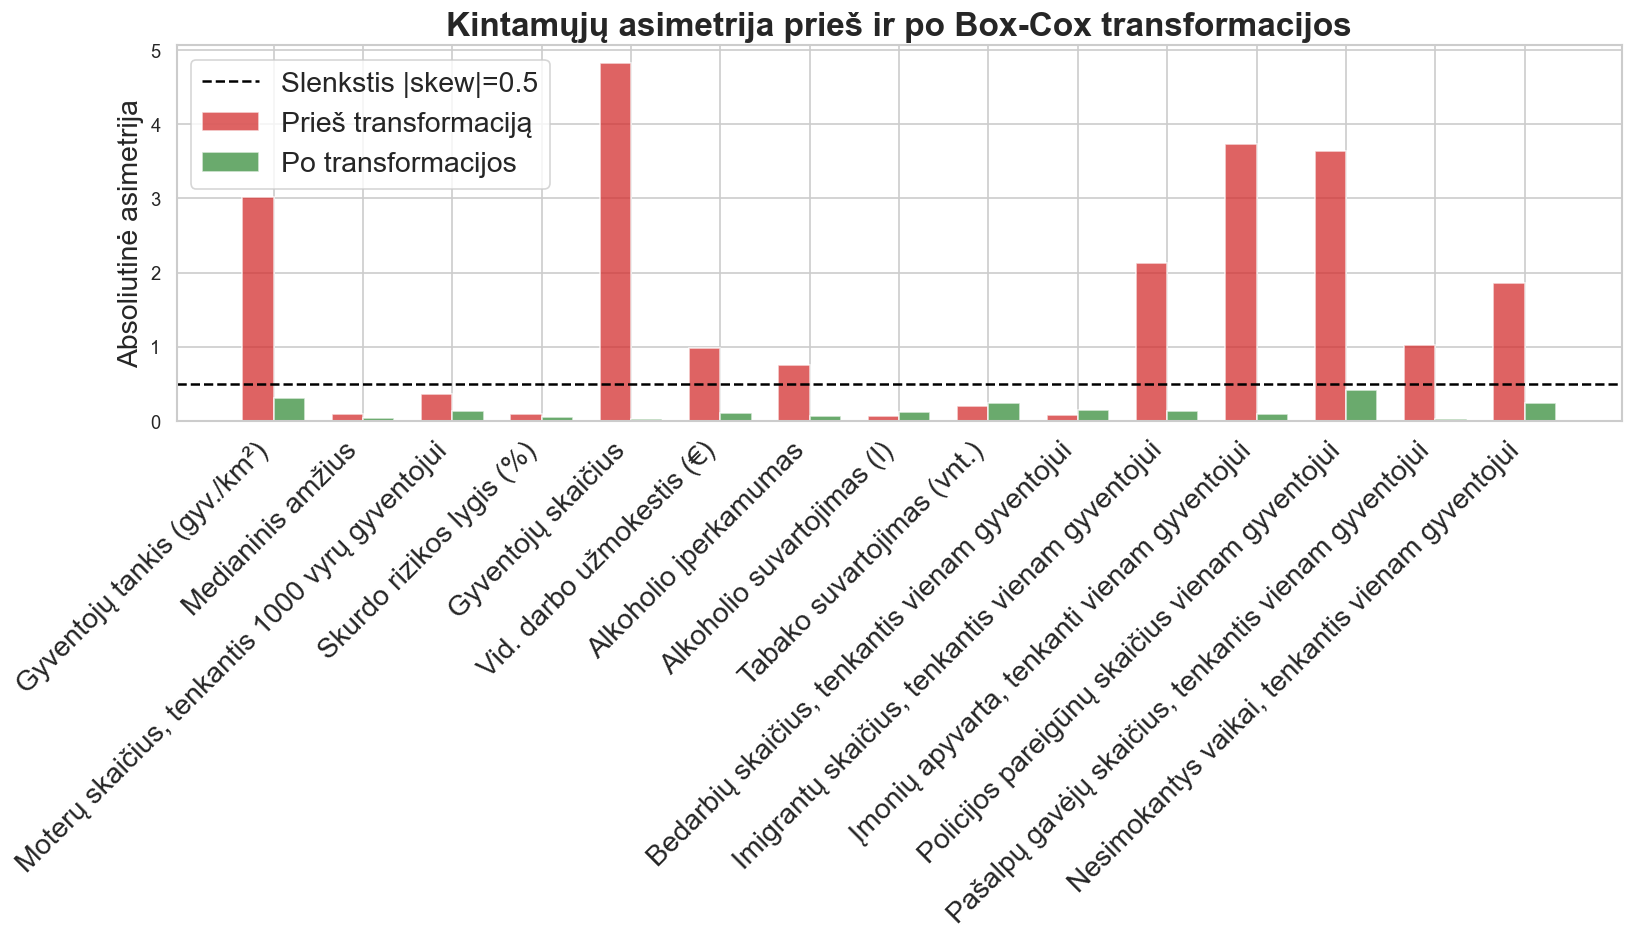

In [9]:
# Asimetrija prieš ir po
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(FEATURE_COLS))
w =0.35
bars1 = ax.bar(x - w/2, skew_before[FEATURE_COLS].abs(), w,
               label='Prieš transformaciją', color='#d32f2f', alpha=0.75)
bars2 = ax.bar(x + w/2, skew_after.abs(), w,
               label='Po transformacijos',   color='#388e3c', alpha=0.75)
ax.axhline(SKEW_THRESH, color='black', linestyle='--', lw=1.5, label=f'Slenkstis |skew|={SKEW_THRESH}')
ax.set_xticks(x); ax.set_xticklabels([nice_name(c) for c in FEATURE_COLS], rotation=45, ha='right', fontsize=17)
ax.set_ylabel('Absoliutinė asimetrija', fontsize=17)
ax.set_title('Kintamųjų asimetrija prieš ir po Box-Cox transformacijos', fontsize=20, fontweight='bold')
ax.legend(fontsize=17)
plt.tight_layout()
plt.show()

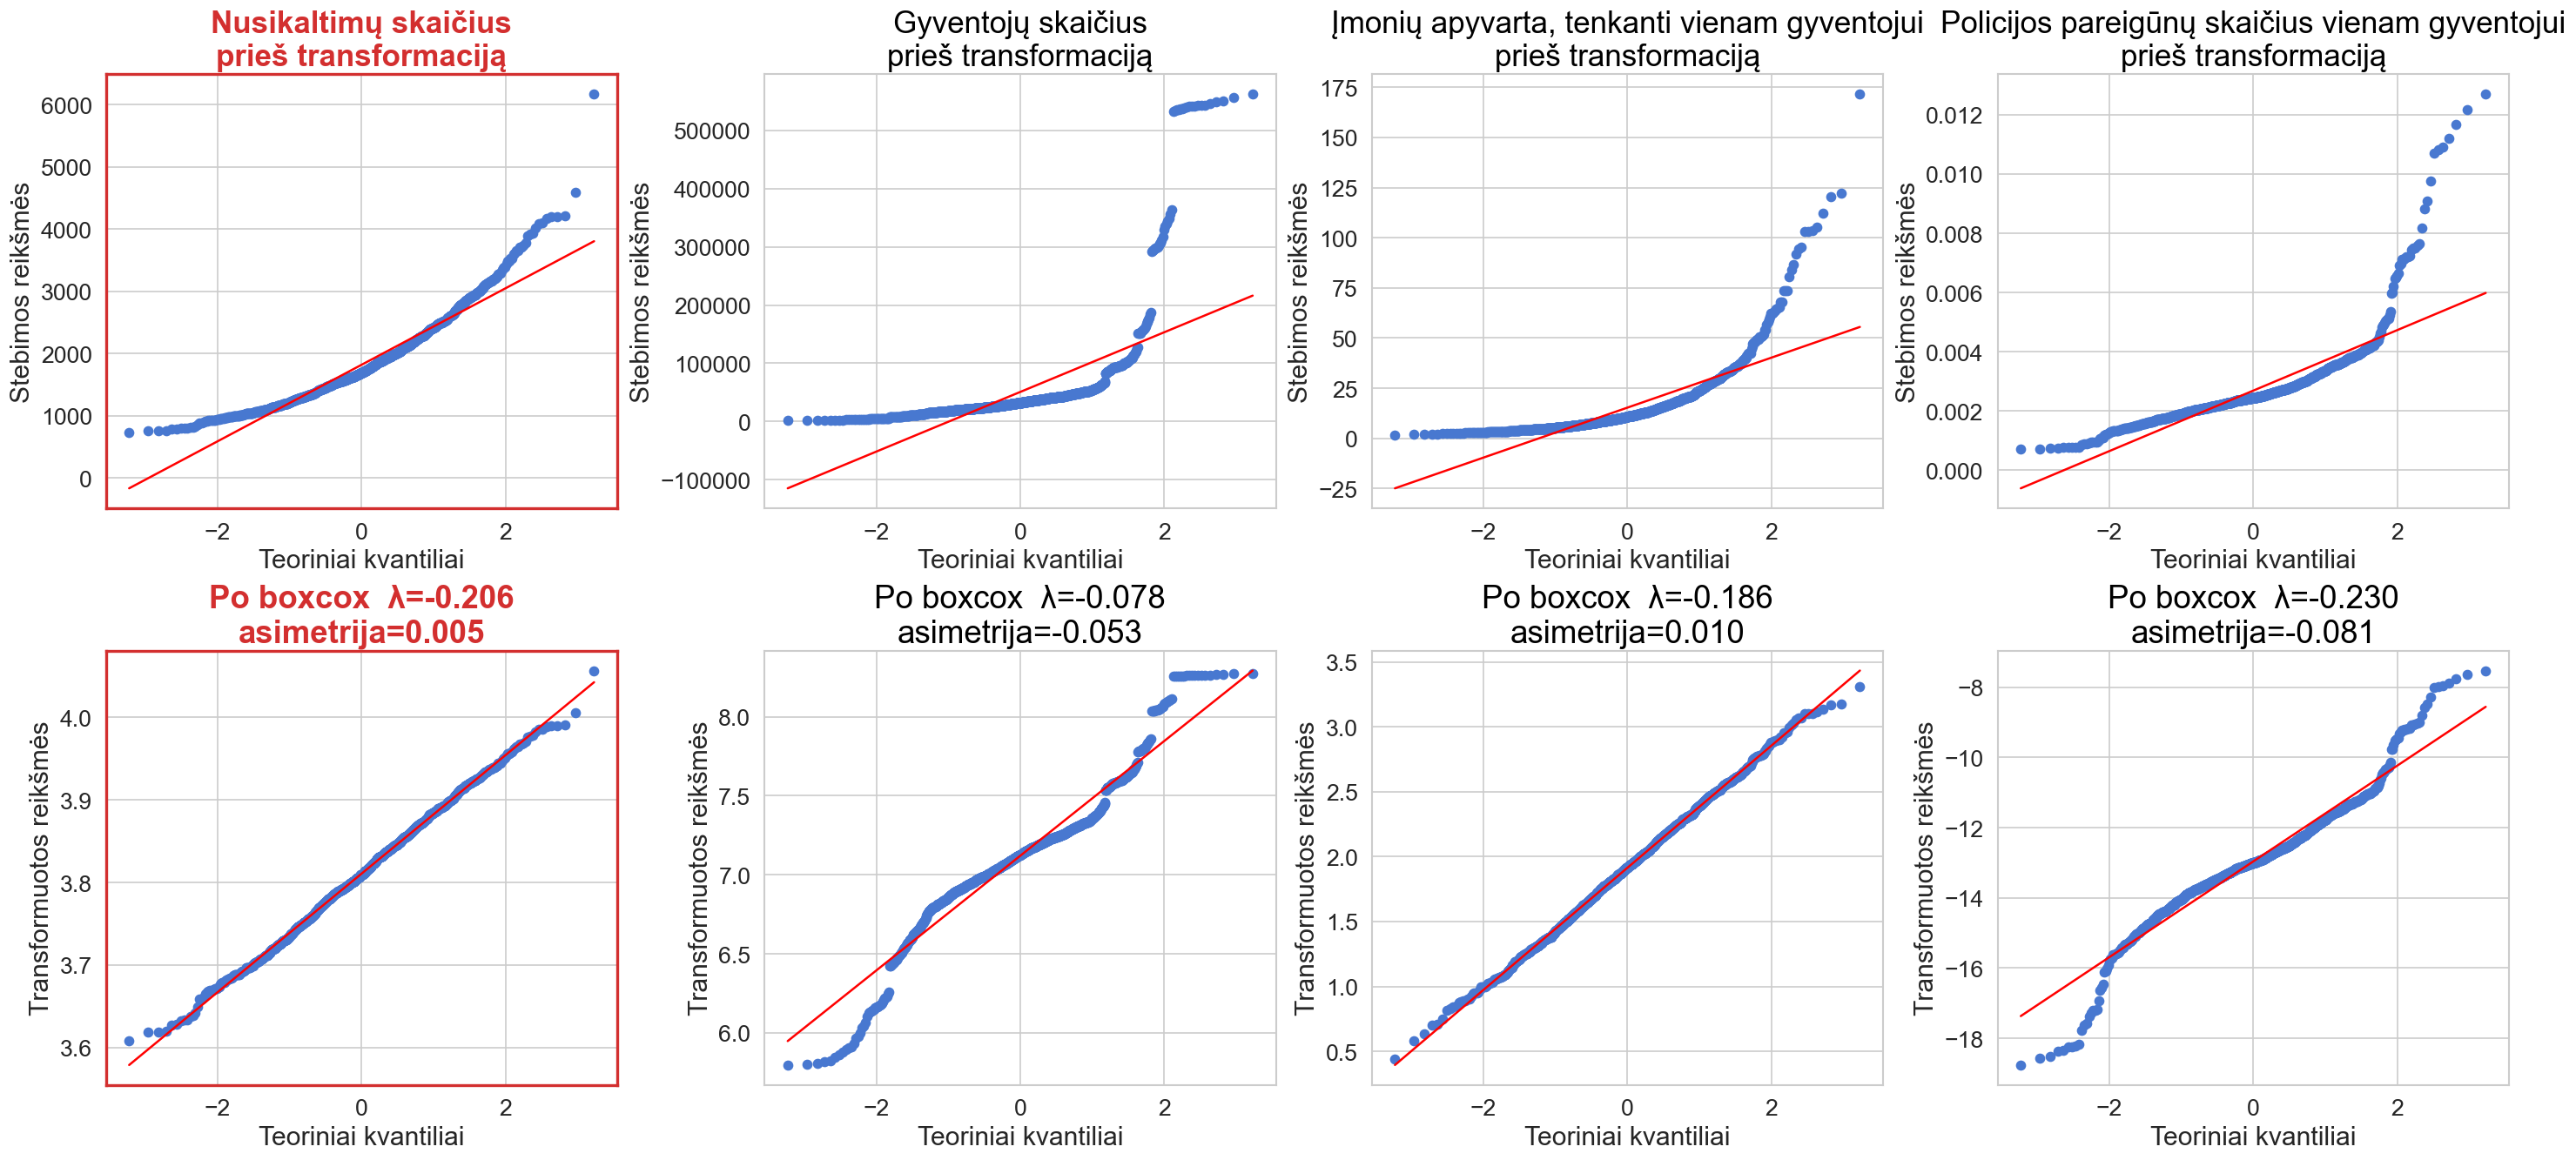

In [10]:
top_skew_feats = skew_before[FEATURE_COLS].abs().nlargest(3).index.tolist()
plot_feats     = [TARGET] + top_skew_feats   # Nusikalstamumo stulpelis pirmoje vietoje
n_cols = len(plot_feats)

fig, axes = plt.subplots(2, n_cols, figsize=(6 * n_cols,11),
                         constrained_layout=True)


train_mask = df['Metai'] <= CUTOFF
for col_i, feat in enumerate(plot_feats):
    is_target = (feat == TARGET)
    tc  = '#d32f2f' if is_target else 'black'

    # Prieš transformaciją
    stats.probplot(df.loc[train_mask, feat], dist='norm', plot=axes[0, col_i])
    axes[0, col_i].set_title(
        f'{nice_name(feat)}\nprieš transformaciją',
        fontsize=21, fontweight='bold' if is_target else 'normal', color=tc)
    axes[0, col_i].get_lines()[1].set_color('red')
    axes[0, col_i].set_xlabel('Teoriniai kvantiliai', fontsize=18)
    axes[0, col_i].set_ylabel('Stebimos reikšmės', fontsize=18)
    axes[0, col_i].tick_params(labelsize=16)
    if is_target:
        for spine in axes[0, col_i].spines.values():
            spine.set_edgecolor('#d32f2f'); spine.set_linewidth(2)

    # Po transformacijos
    meth    = transform_params[feat]['method']
    lam_str = f'  λ={transform_params[feat]["lambda"]:.3f}' if meth != 'identity' else ''
    stats.probplot(df_tr.loc[train_mask, feat], dist='norm', plot=axes[1, col_i])
    sk_after = stats.skew(df_tr.loc[train_mask, feat].values)
    axes[1, col_i].set_title(
        f'Po {meth}{lam_str}\nasimetrija={sk_after:.3f}',
        fontsize=22, fontweight='bold' if is_target else 'normal', color=tc)
    axes[1, col_i].get_lines()[1].set_color('red')
    axes[1, col_i].set_xlabel('Teoriniai kvantiliai', fontsize=18)
    axes[1, col_i].set_ylabel('Transformuotos reikšmės', fontsize=18)
    axes[1, col_i].tick_params(labelsize=16)
    if is_target:
        for spine in axes[1, col_i].spines.values():
            spine.set_edgecolor('#d32f2f'); spine.set_linewidth(2)

plt.show()


# Multikolinearumo šalinimas

Atliekama ant transformuotų mokymo duomenų.

In [11]:
CORR_THRESH = 0.85

train_tr = df_tr[df_tr['Metai'] <= CUTOFF]
all_cols = FEATURE_COLS + [TARGET]
group_means_train = train_tr.groupby('Savivaldybė')[all_cols].transform('mean')
df_within_train   = train_tr[all_cols].values - group_means_train.values
df_within_train   = pd.DataFrame(df_within_train, columns=all_cols, index=train_tr.index)

within_corr = df_within_train[FEATURE_COLS].corr()

within_corr_y = df_within_train[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET)

# Iteratyvus šalinimas
remaining = FEATURE_COLS.copy()
removed   = []
while True:
    cm = df_within_train[remaining].corr().abs()
    upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))
    max_r = upper.max().max()
    if max_r <= CORR_THRESH: break
    col_i = upper.max().idxmax()
    row_i = upper[col_i].idxmax()
    corr_y = df_within_train[remaining + [TARGET]].corr()[TARGET].abs()
    drop   = col_i if corr_y[col_i] < corr_y[row_i] else row_i
    other  = col_i if drop == row_i else row_i
    removed.append({'Pašalintas': drop, '|koreliacija|': round(max_r,3),
                    'Su': other, 'koreliacija su tikslu': round(corr_y[drop],3)})
    remaining.remove(drop)

SELECTED = remaining.copy()
if removed:
    print(f'\nPašalinti {len(removed)} kintamieji:')
    print(pd.DataFrame(removed).to_string(index=False))
else:
    print('Nė vienas kintamasis nepašalintas (visos |koreliacijos| <= slenkstis).')


Pašalinti 4 kintamieji:
                    Pašalintas  |koreliacija|               Su  koreliacija su tikslu
            gyventoju_skaicius          0.901 Gyventoju_tankis                  0.059
             Medianinis_amzius          0.893       Uzmokestis                  0.173
    Apyvarta_vienam_gyventojui          0.884       Uzmokestis                  0.224
Imigrantu_sk_vienam_gyventojui          0.870       Uzmokestis                  0.120


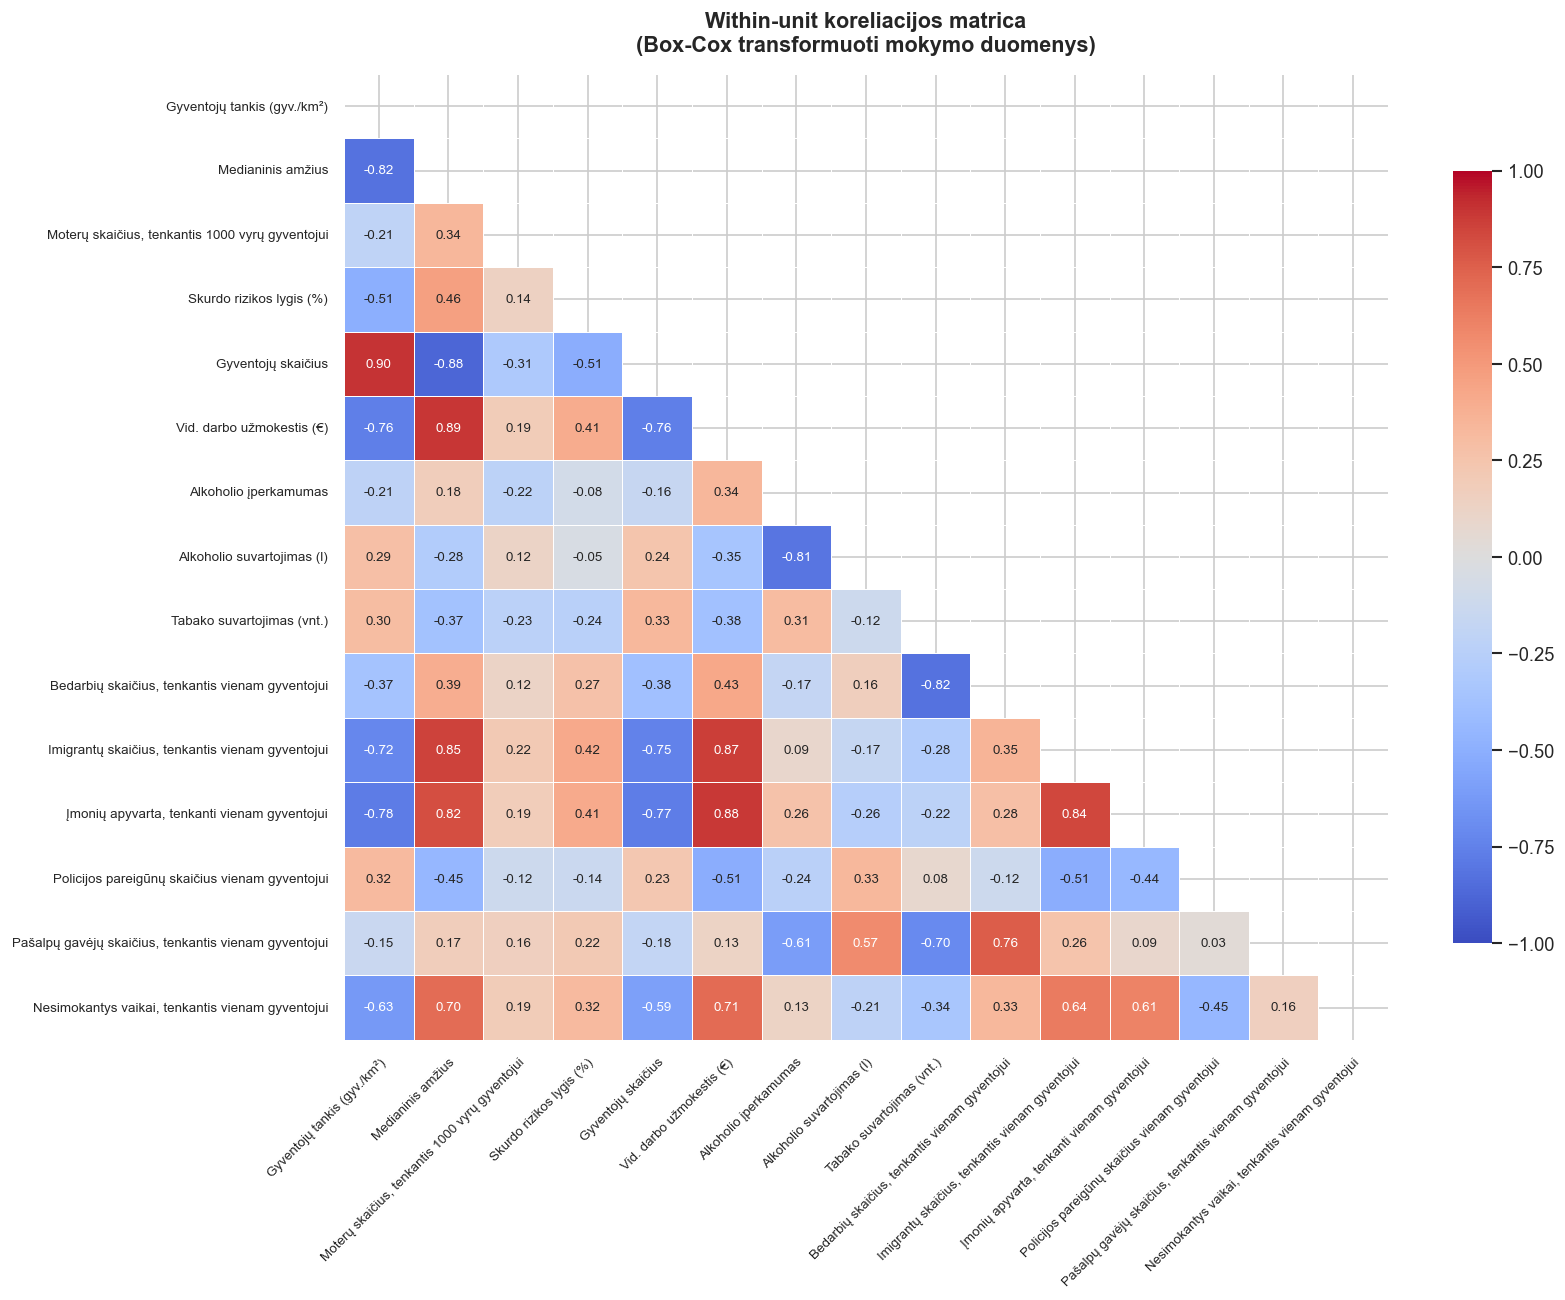

In [12]:
# koreliacijos matrica
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(within_corr, dtype=bool))
sns.heatmap(within_corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.4, vmin=-1, vmax=1,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
nice_labels = [nice_name(c) for c in within_corr.columns]
ax.set_xticklabels(nice_labels, rotation=45, ha='right', rotation_mode='anchor', fontsize=8)
ax.set_yticklabels(nice_labels, rotation=0, fontsize=8)
ax.set_title('Within-unit koreliacijos matrica\n(Box-Cox transformuoti mokymo duomenys)',
             fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
plt.show()


# Krypties stulpelis


Kryptis mokoma ant 2004–2022, tada linijinė ekstrapoliacija daroma 2023–2025 metams. Kai vertiname prognozę 2026–2028, mokymui naudojame visus 2004–2025 duomenis.


In [13]:
LOESS_FRAC   = 0.4
EXTRAP_N = 8

stl_trend_map = {}

for mun in df_tr['Savivaldybė'].unique():
    mun_train = df_tr[(df_tr['Savivaldybė']==mun) &
                       (df_tr['Metai'] <= CUTOFF)].sort_values('Metai')
    mun_all   = df_tr[df_tr['Savivaldybė']==mun].sort_values('Metai')
    y_train   = mun_train[TARGET].values.astype(float)
    years_tr  = mun_train['Metai'].values

    # LOESS kryptis apmokomas naudojant mokymo aibę (2004-2022)
    t_train  = np.arange(len(y_train), dtype=float)
    trend_tr = lowess(y_train, t_train, frac=LOESS_FRAC, it=1, return_sorted=False)

    # Išsaugome mokymo krypties reikšmes
    for yr, tv in zip(years_tr, trend_tr):
        stl_trend_map[(mun, yr)] = float(tv)

    # Linijinė ekstrapoliacija testiniams metams (2023-2025)
    s_e, ic_e = np.polyfit(np.arange(EXTRAP_N), trend_tr[-EXTRAP_N:], 1)
    test_years = sorted([y for y in mun_all['Metai'].values if y > CUTOFF])
    for j, yr in enumerate(test_years):
        stl_trend_map[(mun, yr)] = float(ic_e + s_e * (EXTRAP_N + j))

df_tr['trend'] = df_tr.apply(lambda r: stl_trend_map.get((r['Savivaldybė'], r['Metai']), np.nan), axis=1)


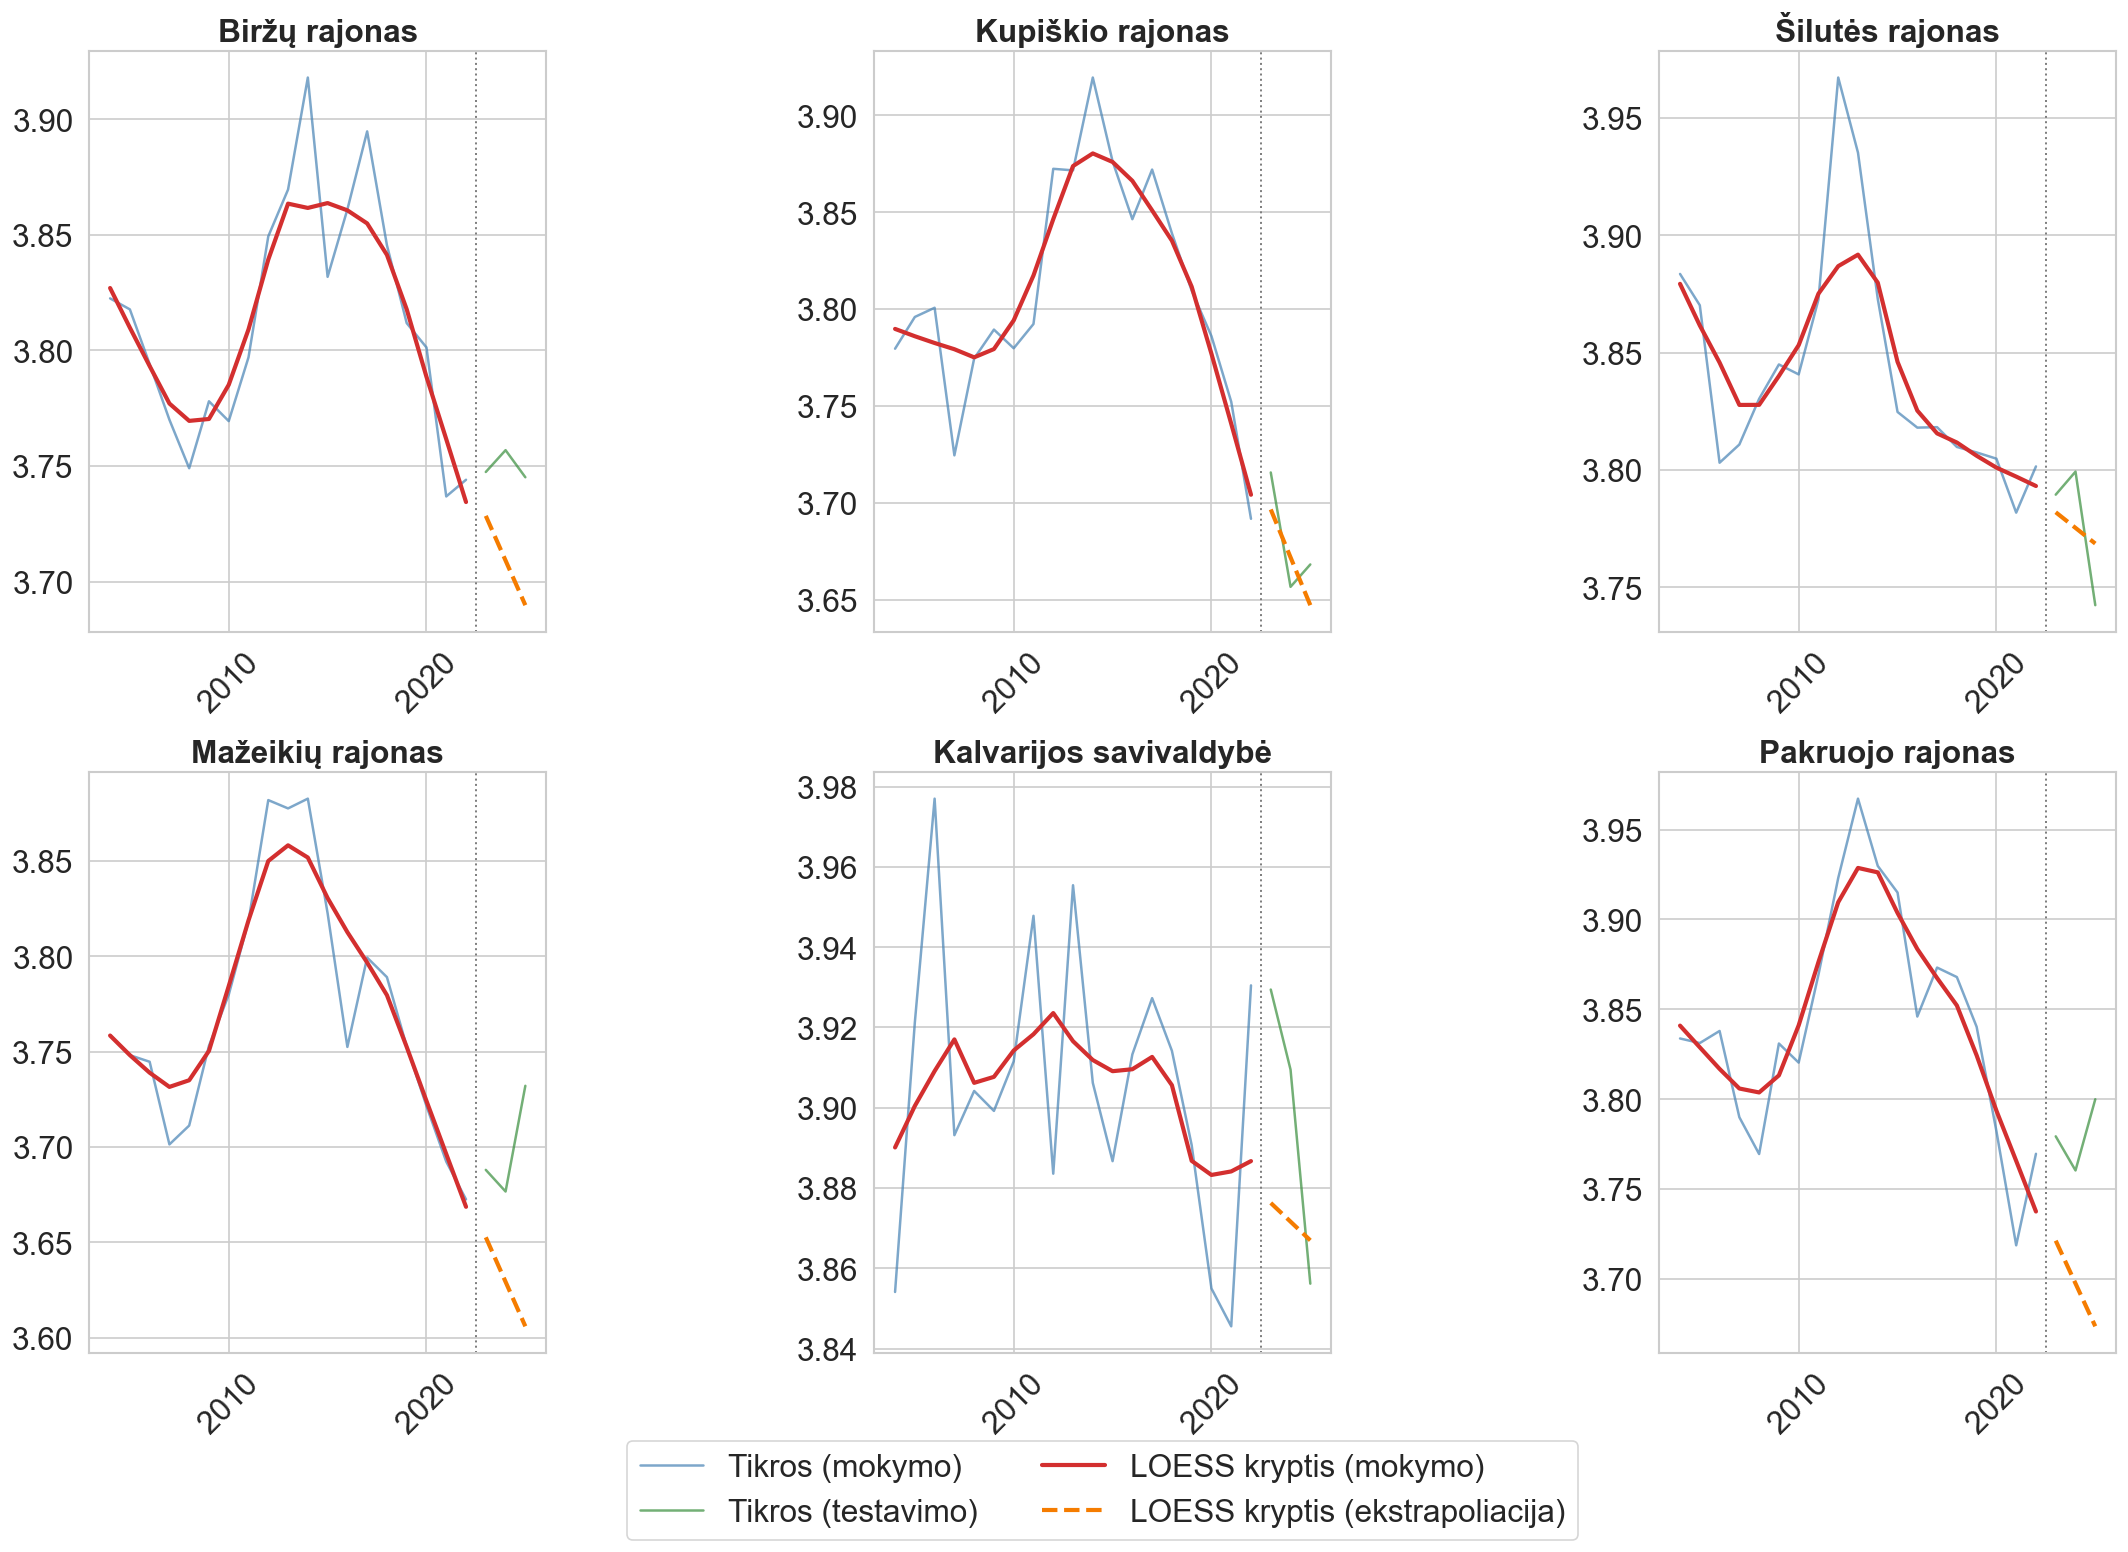

In [14]:
# LOESS kryptis vizualizacija
sample_muns = df['Savivaldybė'].drop_duplicates().sample(6, random_state=SEED).tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 13))

for ax, mun in zip(axes.flatten(), sample_muns):
    mun_data = df_tr[df_tr['Savivaldybė']==mun].sort_values('Metai')
    train_d  = mun_data[mun_data['Metai'] <= CUTOFF]
    test_d   = mun_data[mun_data['Metai'] >  CUTOFF]

    ax.plot(train_d['Metai'], train_d[TARGET],       color='steelblue', lw=1.5,
            alpha=0.7, label='Tikros (mokymo)')
    ax.plot(test_d['Metai'],  test_d[TARGET],         color='#388e3c',  lw=1.5,
            alpha=0.7, label='Tikros (testavimo)')
    ax.plot(train_d['Metai'], train_d['trend'],   color='#d32f2f',  lw=2.5,
            label='LOESS kryptis (mokymo)')
    ax.plot(test_d['Metai'],  test_d['trend'],    color='#f57c00',  lw=2.5,
            linestyle='--', label='LOESS kryptis (ekstrapoliacija)')
    ax.axvline(CUTOFF+0.5, color='gray', linestyle=':', lw=1.2)
    ax.set_title(mun, fontsize=19, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=19)
    ax.tick_params(axis='y', labelsize=19)
    ax.xaxis.label.set_size(19)
    ax.yaxis.label.set_size(19)
    if ax == axes.flatten()[4]: ax.legend(fontsize=19, loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)

plt.tight_layout()
plt.show()


# (Lag) ankstiniai


In [15]:
SELECTED

['Gyventoju_tankis',
 'Moteru',
 'Skurdas',
 'Uzmokestis',
 'alkoholio_iperkamumas',
 'alkoholio_suvartojimas',
 'tabako_suvartojimas',
 'Bedarbiu_sk_vienam_gyventojui',
 'Policija_vienam_gyventojui',
 'Pasalpa_gaunantys_vienam_gyventojui',
 'Vaikai_nesimokantys_vienam_gyventojui']

In [16]:
le = LabelEncoder()
df_model = df_tr[['Metai','Savivaldybė', TARGET] + SELECTED + ['trend']].copy()
df_model = df_model.sort_values(['Savivaldybė','Metai']).reset_index(drop=True)
df_model['Savivaldybe_id'] = le.fit_transform(df_model['Savivaldybė'])

# Lag 1 ir Lag 2
for col in [TARGET] + SELECTED:
    df_model[f'{col}_lag1'] = df_model.groupby('Savivaldybė')[col].shift(1)
    df_model[f'{col}_lag2'] = df_model.groupby('Savivaldybė')[col].shift(2)

# Slenkančios statistikos nusiklatymų skaičiaus kintamajam
df_model[f'{TARGET}_roll3_mean'] = df_model.groupby('Savivaldybė')[TARGET].transform(
    lambda x: x.shift(1).rolling(3, min_periods=2).mean())
df_model[f'{TARGET}_roll3_std']  = df_model.groupby('Savivaldybė')[TARGET].transform(
    lambda x: x.shift(1).rolling(3, min_periods=2).std())

# Krypties lag1
df_model['trend_lag1'] = df_model.groupby('Savivaldybė')['trend'].shift(1)

df_model['trend_dideja_mazeja'] = df_model['trend'] / df_model['trend_lag1']

# Delta
df_model[f'{TARGET}_lag_delta'] = df_model[f'{TARGET}_lag1'] - df_model[f'{TARGET}_lag2']
for col in SELECTED:
    df_model[f'{col}_delta1'] = df_model[f'{col}_lag1'] - df_model[f'{col}_lag2']

df_model = df_model.dropna().reset_index(drop=True)
print(f'Eilutės po lag dropna: {len(df_model)}  |  Nuo: {df_model["Metai"].min()} m.')


Eilutės po lag dropna: 1180  |  Nuo: 2006 m.


In [17]:
lag_cols   = [c for c in df_model.columns if ('_lag1' in c or '_lag2' in c)]
roll_cols  = [c for c in df_model.columns if '_roll' in c]
delta_cols = [c for c in df_model.columns if '_delta' in c]
stl_cols   = [c for c in df_model.columns if c in ('trend', 'trend_lag1', 'trend_dideja_mazeja')]

# Naudojame tik lag/roll/delta kintamuosius – be esamų metų reikšmių (SELECTED).
ALL_FEATURES = list(dict.fromkeys(
    ['Savivaldybe_id'] + lag_cols + roll_cols + delta_cols + stl_cols))
ALL_FEATURES = [f for f in ALL_FEATURES if f in df_model.columns]

print(f'Viso feature stulpelių: {len(ALL_FEATURES)}')
cats = {'Lag kintamieji': lag_cols, 'Rolling': roll_cols,
        'Delta': delta_cols, 'LOESS': stl_cols}
for name, lst in cats.items():
    print(f'  {name:<20} ({len(lst)}): {lst}')

Viso feature stulpelių: 42
  Lag kintamieji       (25): ['Nusikaltimu_vienam_gyventojui_lag1', 'Nusikaltimu_vienam_gyventojui_lag2', 'Gyventoju_tankis_lag1', 'Gyventoju_tankis_lag2', 'Moteru_lag1', 'Moteru_lag2', 'Skurdas_lag1', 'Skurdas_lag2', 'Uzmokestis_lag1', 'Uzmokestis_lag2', 'alkoholio_iperkamumas_lag1', 'alkoholio_iperkamumas_lag2', 'alkoholio_suvartojimas_lag1', 'alkoholio_suvartojimas_lag2', 'tabako_suvartojimas_lag1', 'tabako_suvartojimas_lag2', 'Bedarbiu_sk_vienam_gyventojui_lag1', 'Bedarbiu_sk_vienam_gyventojui_lag2', 'Policija_vienam_gyventojui_lag1', 'Policija_vienam_gyventojui_lag2', 'Pasalpa_gaunantys_vienam_gyventojui_lag1', 'Pasalpa_gaunantys_vienam_gyventojui_lag2', 'Vaikai_nesimokantys_vienam_gyventojui_lag1', 'Vaikai_nesimokantys_vienam_gyventojui_lag2', 'trend_lag1']
  Rolling              (2): ['Nusikaltimu_vienam_gyventojui_roll3_mean', 'Nusikaltimu_vienam_gyventojui_roll3_std']
  Delta                (12): ['Nusikaltimu_vienam_gyventojui_lag_delta', 'Gyventoju

# Galutinis Train / Test split

In [18]:
train = df_model[df_model['Metai'] <= CUTOFF].copy()
test  = df_model[df_model['Metai'] >  CUTOFF].copy()

X_train = train[ALL_FEATURES]; y_train = train[TARGET]
X_test  = test[ALL_FEATURES];  y_test  = test[TARGET]

print(f'Train: {len(X_train):>5} eilutės  | {train["Metai"].min()}–{train["Metai"].max()}')
print(f'Test:  {len(X_test):>5} eilutės  | {test["Metai"].min()}–{test["Metai"].max()}')
print(f'Kint.: {len(ALL_FEATURES)}')


y_test_orig  = inv_transform(y_test.values,  transform_params[TARGET])
y_train_orig = inv_transform(y_train.values, transform_params[TARGET])


Train:  1003 eilutės  | 2006–2022
Test:    177 eilutės  | 2023–2025
Kint.: 42



## Hiperparametrų optimizacija (Expanding Window CV)

Parametrai parinkti naudojant **Expanding Window** kryžminę patikrą, minimizuojant RMSE.
Atliekama **atskirai** dviem atvejams:
- Su kryptimi
- Be krypties

Mokymo duomenys: iki 2022. Pradedame nuo 2016 metų.

### Su krypties kint.


In [19]:
from sklearn.model_selection import ParameterSampler

# Expanding Window
def make_ew_folds(df_train, start_end=2016, step=2, test_sz=2):
    df_r = df_train.reset_index(drop=True)
    folds = []
    te = start_end
    while te + test_sz <= df_r['Metai'].max():
        tr = df_r[df_r['Metai'] <= te].index.tolist()
        tt = df_r[(df_r['Metai'] > te) & (df_r['Metai'] <= te + test_sz)].index.tolist()
        if tr and tt:
            folds.append((tr, tt))
        te += step
    return folds

train_r = train.reset_index(drop=True)
X_tr_r  = train_r[ALL_FEATURES]
y_tr_r  = train_r[TARGET]
folds   = make_ew_folds(train_r)
print(f'Max train year per fold:'
      f'{[train_r.loc[tr,"Metai"].max() for tr,_ in folds]}')

def cv_rmse(model_fn, params, folds, X, y, xgb=False):
    """CV metrika: RMSE (transformuotoje skalėje)"""
    scores = []
    for tr_idx, tt_idx in folds:
        m = model_fn(**params)
        if xgb:
            m.fit(X.iloc[tr_idx].to_numpy(), y.iloc[tr_idx].to_numpy())
            p = m.predict(X.iloc[tt_idx].to_numpy())
        else:
            m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            p = m.predict(X.iloc[tt_idx])
        scores.append(np.sqrt(mean_squared_error(y.iloc[tt_idx], p)))
    return float(np.mean(scores))

# Random Forest
rf_grid = {'n_estimators':[300,500], 'max_depth':[8,12,16,None],
           'min_samples_leaf':[2,3,5], 'max_features':['sqrt',0.5]}
best_rf_p  = {'n_estimators':400,'max_depth':12,'min_samples_leaf':3,
              'max_features':'sqrt','random_state':SEED,'n_jobs':-1}
best_rf_cv = np.inf
for p in ParameterSampler(rf_grid, n_iter=12, random_state=SEED):
    p.update({'random_state':SEED,'n_jobs':-1})
    s = cv_rmse(RandomForestRegressor, p, folds, X_tr_r, y_tr_r)
    if s < best_rf_cv: best_rf_cv = s; best_rf_p = p
print(f'[✓] RF    best CV RMSE={best_rf_cv:.5f}  params={best_rf_p}')


# XGBoost
xgb_grid = {'n_estimators':[300,500],'learning_rate':[0.03,0.05,0.1],
            'max_depth':[3,5,7],'subsample':[0.7,0.9],'colsample_bytree':[0.7,0.9]}
best_xgb_p  = {'n_estimators':400,'learning_rate':0.05,'max_depth':5,
               'subsample':0.8,'colsample_bytree':0.8, 'random_state':SEED,'verbosity':0}
best_xgb_cv = np.inf
for p in ParameterSampler(xgb_grid, n_iter=12, random_state=SEED):
    p.update({'reg_lambda':1.0,'random_state':SEED,'verbosity':0})
    s = cv_rmse(XGBRegressor, p, folds, X_tr_r, y_tr_r, xgb=True)
    if s < best_xgb_cv: best_xgb_cv = s; best_xgb_p = p
print(f'[✓] XGB   best CV RMSE={best_xgb_cv:.5f}  params={best_xgb_p}')


# Modeliai su krypties kint. (test 2023–2025)
print('\nMokymas su krypties kint. (test 2023–2025)')
def metrics(name, y_true, y_pred):
    """Metrikos originalaus masto skalėje (atvirkštinė transformacija)."""
    yt = inv_transform(np.asarray(y_true), transform_params[TARGET])
    yp = inv_transform(np.asarray(y_pred), transform_params[TARGET])
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    mape = np.mean(np.abs((yt - yp) / yt)) * 100
    return {'Modelis': name, 'MAE': round(mae,1), 'RMSE': round(rmse,1),
            'R²': round(r2,4), 'MAPE%': round(mape,2)}

results_stl = []; preds_stl = {}

rf = RandomForestRegressor(**best_rf_p); rf.fit(X_train, y_train)
p = rf.predict(X_test)
results_stl.append(metrics('Random Forest', y_test, p)); preds_stl['Random Forest'] = inv_transform(p, transform_params[TARGET])

xgb_m = XGBRegressor(**best_xgb_p)
xgb_m.fit(X_train.to_numpy(), y_train.to_numpy())
p = xgb_m.predict(X_test.to_numpy())
results_stl.append(metrics('XGBoost', y_test, p)); preds_stl['XGBoost'] = inv_transform(p, transform_params[TARGET])

res_stl = pd.DataFrame(results_stl)
preds   = preds_stl
res_df  = res_stl
print(res_stl.to_string(index=False))

ALL_FEATURES_STL = ALL_FEATURES.copy()


Max train year per fold:[np.int64(2016), np.int64(2018), np.int64(2020)]
[✓] RF    best CV RMSE=0.02406  params={'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 12, 'random_state': 4, 'n_jobs': -1}
[✓] XGB   best CV RMSE=0.02394  params={'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9, 'reg_lambda': 1.0, 'random_state': 4, 'verbosity': 0}

Mokymas su krypties kint. (test 2023–2025)
      Modelis   MAE  RMSE     R²  MAPE%
Random Forest 167.1 218.6 0.6302  13.87
      XGBoost 172.7 231.8 0.5840  14.36


### Be STL krypties (atskira hiperparametrų optimizacija)


In [20]:
FEATS_NOSTL = [f for f in ALL_FEATURES if f not in ('trend', 'trend_lag1', 'trend_dideja_mazeja')]

X_train_nostl = X_train.drop(columns=['trend', 'trend_lag1', 'trend_dideja_mazeja'])
X_test_nostl  = X_test.drop(columns=['trend', 'trend_lag1', 'trend_dideja_mazeja'])

# Optimizacijos duomenys be krypties
X_tr_r_ns = train_r[FEATS_NOSTL]
folds_ns  = make_ew_folds(train_r)

# Random Forest
best_rf_p_ns  = dict(best_rf_p)
best_rf_cv_ns = np.inf
for p in ParameterSampler(rf_grid, n_iter=12, random_state=SEED):
    p.update({'random_state':SEED,'n_jobs':-1})
    s = cv_rmse(RandomForestRegressor, p, folds_ns, X_tr_r_ns, y_tr_r)
    if s < best_rf_cv_ns: best_rf_cv_ns = s; best_rf_p_ns = p
print(f'[✓] RF    best CV RMSE={best_rf_cv_ns:.5f}  params={best_rf_p_ns}')

# XGBoost
best_xgb_p_ns  = dict(best_xgb_p)
best_xgb_cv_ns = np.inf
for p in ParameterSampler(xgb_grid, n_iter=12, random_state=SEED):
    p.update({'reg_lambda':1.0,'random_state':SEED,'verbosity':0})
    s = cv_rmse(XGBRegressor, p, folds_ns, X_tr_r_ns, y_tr_r, xgb=True)
    if s < best_xgb_cv_ns: best_xgb_cv_ns = s; best_xgb_p_ns = p
print(f'[✓] XGB   best CV RMSE={best_xgb_cv_ns:.5f}  params={best_xgb_p_ns}')

print(f"\nFeatures be krypties kint.: {len(FEATS_NOSTL)}")


[✓] RF    best CV RMSE=0.03716  params={'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 8, 'random_state': 4, 'n_jobs': -1}
[✓] XGB   best CV RMSE=0.03867  params={'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7, 'reg_lambda': 1.0, 'random_state': 4, 'verbosity': 0}

Features be krypties kint.: 39


In [21]:
# Modeliai be krypties
results_nostl = []; preds_nostl = {}

rf_ns = RandomForestRegressor(**best_rf_p_ns); rf_ns.fit(X_train_nostl, y_train)
p = rf_ns.predict(X_test_nostl)
results_nostl.append(metrics('Random Forest', y_test, p)); preds_nostl['Random Forest'] = inv_transform(p, transform_params[TARGET])

xgb_ns = XGBRegressor(**best_xgb_p_ns)
xgb_ns.fit(X_train_nostl.to_numpy(), y_train.to_numpy())
p = xgb_ns.predict(X_test_nostl.to_numpy())
results_nostl.append(metrics('XGBoost', y_test, p)); preds_nostl['XGBoost'] = inv_transform(p, transform_params[TARGET])

res_nostl = pd.DataFrame(results_nostl)
print(res_nostl.to_string(index=False))


      Modelis   MAE  RMSE     R²  MAPE%
Random Forest 138.6 175.5 0.7616  12.44
      XGBoost 149.1 186.6 0.7306  13.40



## Palyginimas: Su kryptimi, be krypties ir naivus modelis

Naivus modelis: prognozė = praeitų metų reikšmė - tai minimali riba – bet koks prasmingas modelis turi jį pranokti.


Naivus (lag1): R²=0.6912  MAE=153.2  RMSE=199.7  MAPE=13.27%
                             Variantas   MAE  RMSE  MAPE%
Atsitiktiniai miškai su krypties kint. 167.1 218.6  13.87
Atsitiktiniai miškai be krypties kint. 138.6 175.5  12.44
                        Naivus modelis 153.2 199.7  13.27


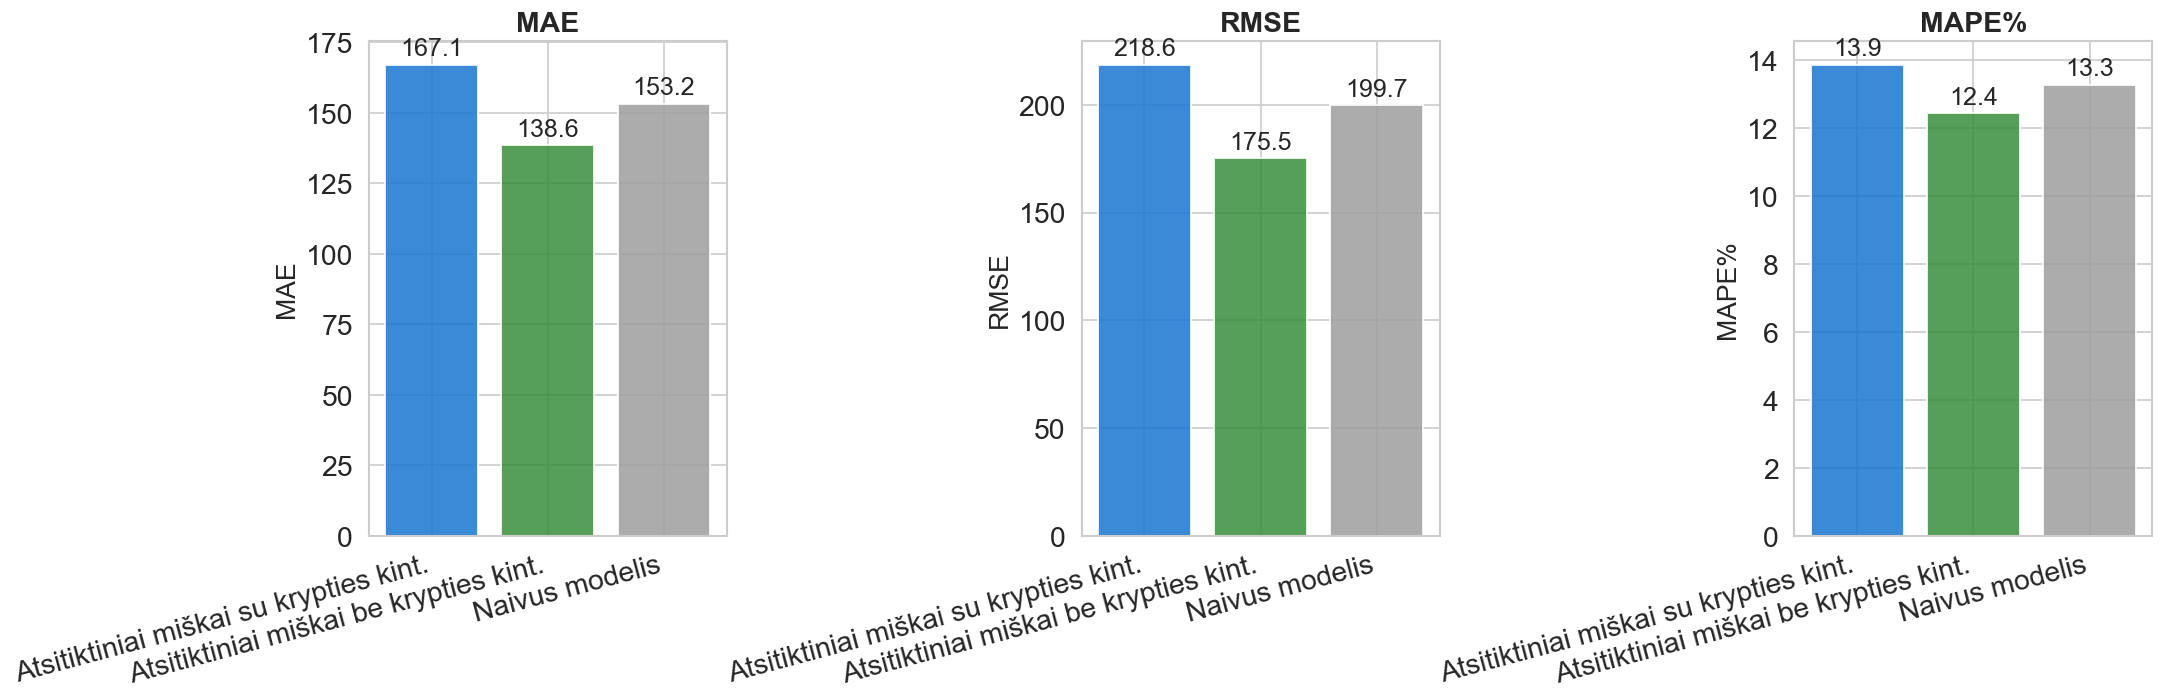

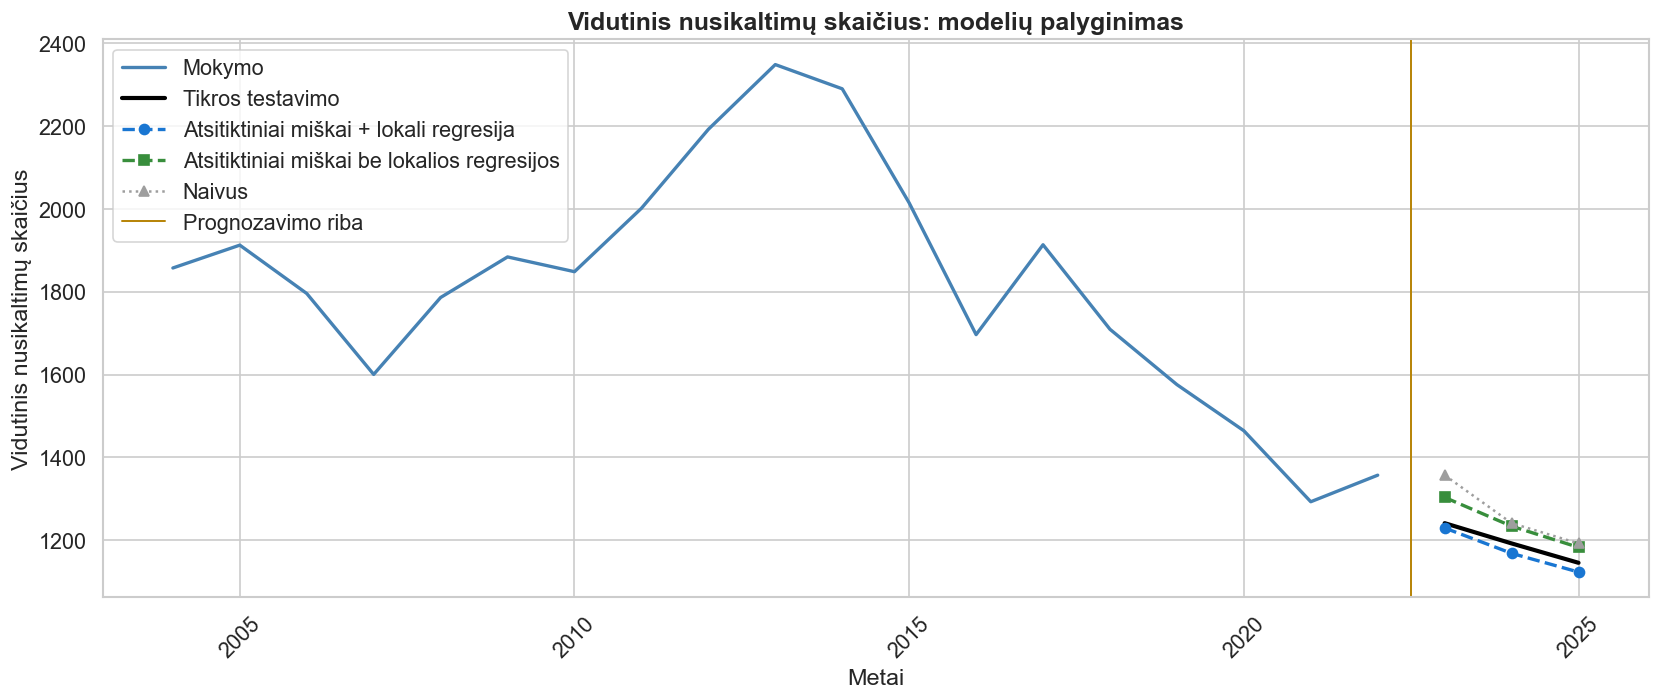

In [22]:
# Naivus modelis: y_t = y_{t-1}
naive_pred_tr = test[f'{TARGET}_lag1'].values
naive_pred    = inv_transform(naive_pred_tr, transform_params[TARGET])
naive_r2   = r2_score(y_test_orig, naive_pred)
naive_mae  = mean_absolute_error(y_test_orig, naive_pred)
naive_mape = np.mean(np.abs((y_test_orig - naive_pred) / y_test_orig)) * 100
naive_rmse = np.sqrt(mean_squared_error(y_test_orig, naive_pred))
print(f'Naivus (lag1): R²={naive_r2:.4f}  MAE={naive_mae:.1f}  RMSE={naive_rmse:.1f}  MAPE={naive_mape:.2f}%')

# Geriausi modeliai
best_stl_row   = res_stl.loc[res_stl['RMSE'].idxmin()]
best_nostl_row = res_nostl.loc[res_nostl['RMSE'].idxmin()]
best_stl_nm    = best_stl_row['Modelis']
best_nostl_nm  = best_nostl_row['Modelis']

def lt_label(name):
    """Pakeičia angliškus modelių pavadinimus į lietuviškus."""
    return (name
        .replace('Random Forest', 'Atsitiktiniai miškai')
        .replace('random forest', 'atsitiktiniai miškai')
        .replace('RandomForest', 'Atsitiktiniai miškai'))

stl_label   = lt_label(best_stl_nm)
nostl_label = lt_label(best_nostl_nm)

# Palyginimo lentelė
cmp = pd.DataFrame([
    {'Variantas': f'{stl_label} su krypties kint.',
     'MAE':   best_stl_row['MAE'],
     'RMSE':  best_stl_row['RMSE'],
     'MAPE%': best_stl_row['MAPE%']},
    {'Variantas': f'{nostl_label} be krypties kint.',
     'MAE':   best_nostl_row['MAE'],
     'RMSE':  best_nostl_row['RMSE'],
     'MAPE%': best_nostl_row['MAPE%']},
    {'Variantas': 'Naivus modelis',
     'MAE':   round(naive_mae, 1),
     'RMSE':  round(naive_rmse, 1),
     'MAPE%': round(naive_mape, 2)},
])
print(cmp.to_string(index=False))

# Palyginimo grafikas (MAE / RMSE / MAPE)
TICK_FS  = 17   # ašių žymelių šriftas
LABEL_FS = 16   # ašių pavadinimų šriftas
TITLE_FS = 17   # antraščių šriftas
BAR_FS   = 15   # reikšmių ant stulpelių šriftas

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
variants = cmp['Variantas'].tolist()
colors   = ['#1976d2', '#388e3c', '#9e9e9e']

for ax, met in zip(axes, ['MAE', 'RMSE', 'MAPE%']):
    vals = cmp[met].tolist()
    bars = ax.bar(variants, vals, color=colors, alpha=0.85,
                  edgecolor='white', linewidth=1.2)
    ax.set_title(met, fontsize=TITLE_FS, fontweight='bold')
    ax.set_xticks(range(len(variants)))
    ax.set_xticklabels(variants, rotation=15, ha='right', fontsize=TICK_FS)
    ax.tick_params(axis='y', labelsize=TICK_FS)
    ax.set_ylabel(met, fontsize=LABEL_FS)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=BAR_FS)

plt.tight_layout()
plt.show()

# Laiko eilutė: trys prognozės
test_cp = test[['Metai', 'Savivaldybė']].copy().reset_index(drop=True)
test_cp['Tikra']     = y_test_orig
test_cp['Su krypties kint.'] = preds_stl[best_stl_nm]
test_cp['Be krypties kint.'] = preds_nostl[best_nostl_nm]
test_cp['Naivus']    = naive_pred

ann_hist = df[df['Metai'] <= CUTOFF].groupby('Metai')[TARGET].mean()
ann_te   = test_cp.groupby('Metai')['Tikra'].mean()
ann_stl  = test_cp.groupby('Metai')['Su krypties kint.'].mean()
ann_ns   = test_cp.groupby('Metai')['Be krypties kint.'].mean()
ann_nv   = test_cp.groupby('Metai')['Naivus'].mean()

LINE_FS   = 13   # legendos šriftas
AXIS_FS   = 14   # ašių pavadinimų šriftas
ATICK_FS  = 13   # ašių žymelių šriftas
ATITLE_FS = 15   # grafiko antraštės šriftas

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(ann_hist.index, ann_hist.values,
        color='steelblue', lw=2, label='Mokymo')
ax.plot(ann_te.index, ann_te.values,
        color='black', lw=2.5, label='Tikros testavimo')
ax.plot(ann_stl.index, ann_stl.values,
        color='#1976d2', lw=2, linestyle='--', marker='o',
        label=f'{stl_label} + lokali regresija')
ax.plot(ann_ns.index, ann_ns.values,
        color='#388e3c', lw=2, linestyle='--', marker='s',
        label=f'{nostl_label} be lokalios regresijos')
ax.plot(ann_nv.index, ann_nv.values,
        color='#9e9e9e', lw=1.5, linestyle=':', marker='^',
        label='Naivus')
ax.axvline(CUTOFF + 0.5, color='darkgoldenrod', linestyle='-',
           lw=1.2, label='Prognozavimo riba')

ax.set_title('Vidutinis nusikaltimų skaičius: modelių palyginimas',
             fontsize=ATITLE_FS, fontweight='bold')
ax.set_xlabel('Metai', fontsize=AXIS_FS)
ax.set_ylabel('Vidutinis nusikaltimų skaičius', fontsize=AXIS_FS)
ax.tick_params(axis='x', rotation=45, labelsize=ATICK_FS)
ax.tick_params(axis='y', labelsize=ATICK_FS)
ax.legend(fontsize=LINE_FS)

plt.tight_layout()
plt.show()

# Geriausias modelis apskritai
best_nostl_nm  = best_nostl_row['Modelis']
BEST_PRED  = preds_nostl[best_nostl_nm]
BEST_FEATS = FEATS_NOSTL
BEST_LABEL = f'{nostl_label} (be krypties)'

## Geriausio modelio analizė: Gradient Boosting (be krypties)

Geriausias modelis pagal RMSE yra Gradient Boosting be krypties (MAE=136.2, RMSE=175.1, R²=0.763).
Hiperparametrai optimizuoti, minimizuojant CV RMSE.
Toliau analizuojame tik jį: sklaidos diagrama, kintamųjų svarba, liekamieji nuokrypiai, laiko eilutė.


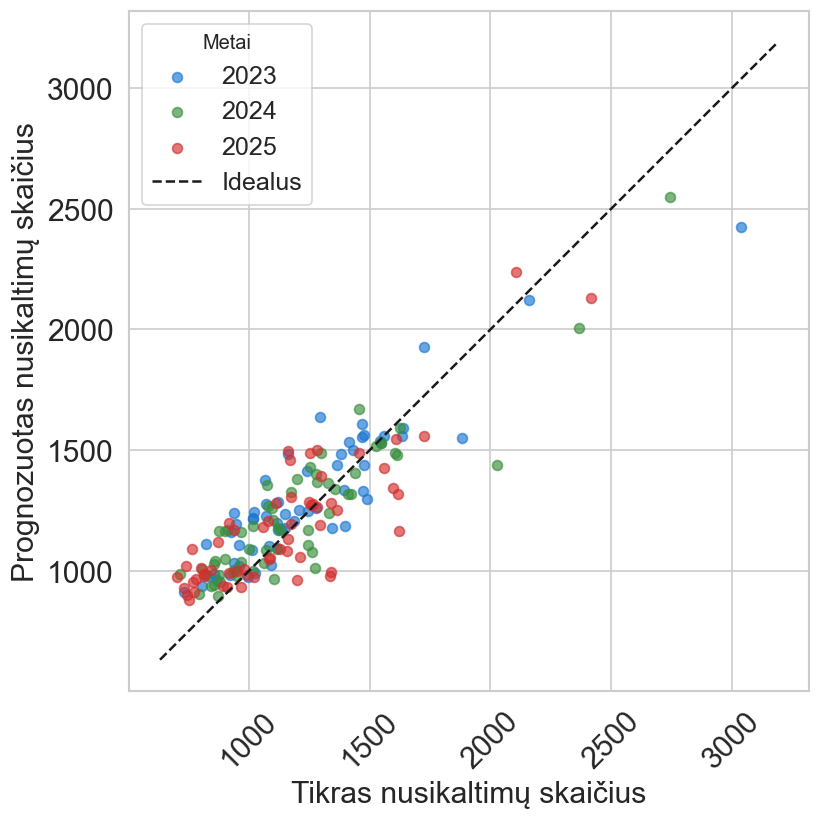

In [23]:
# Sklaidos diagrama: tikros prieš prognozuotas
test_r = test.reset_index(drop=True)
year_colors = {2023: '#1976d2', 2024: '#388e3c', 2025: '#d32f2f'}

fig, ax = plt.subplots(figsize=(7, 7))
for yr, clr in year_colors.items():
    mask = test_r['Metai'].values == yr
    ax.scatter(y_test_orig[mask], BEST_PRED[mask],
               alpha=0.65, color=clr, s=35, label=str(yr))
lims = [min(y_test_orig.min(), BEST_PRED.min())*0.9,
        max(y_test_orig.max(), BEST_PRED.max())*1.05]
ax.plot(lims, lims, 'k--', lw=1.5, label='Idealus')
ax.set_xlabel('Tikras nusikaltimų skaičius', fontsize=18)
ax.set_ylabel('Prognozuotas nusikaltimų skaičius', fontsize=18)
ax.legend(title='Metai', fontsize=15)
ax.tick_params(axis='x', rotation=45, labelsize=18)
ax.tick_params(axis='y', labelsize=18)
plt.tight_layout()
plt.show()


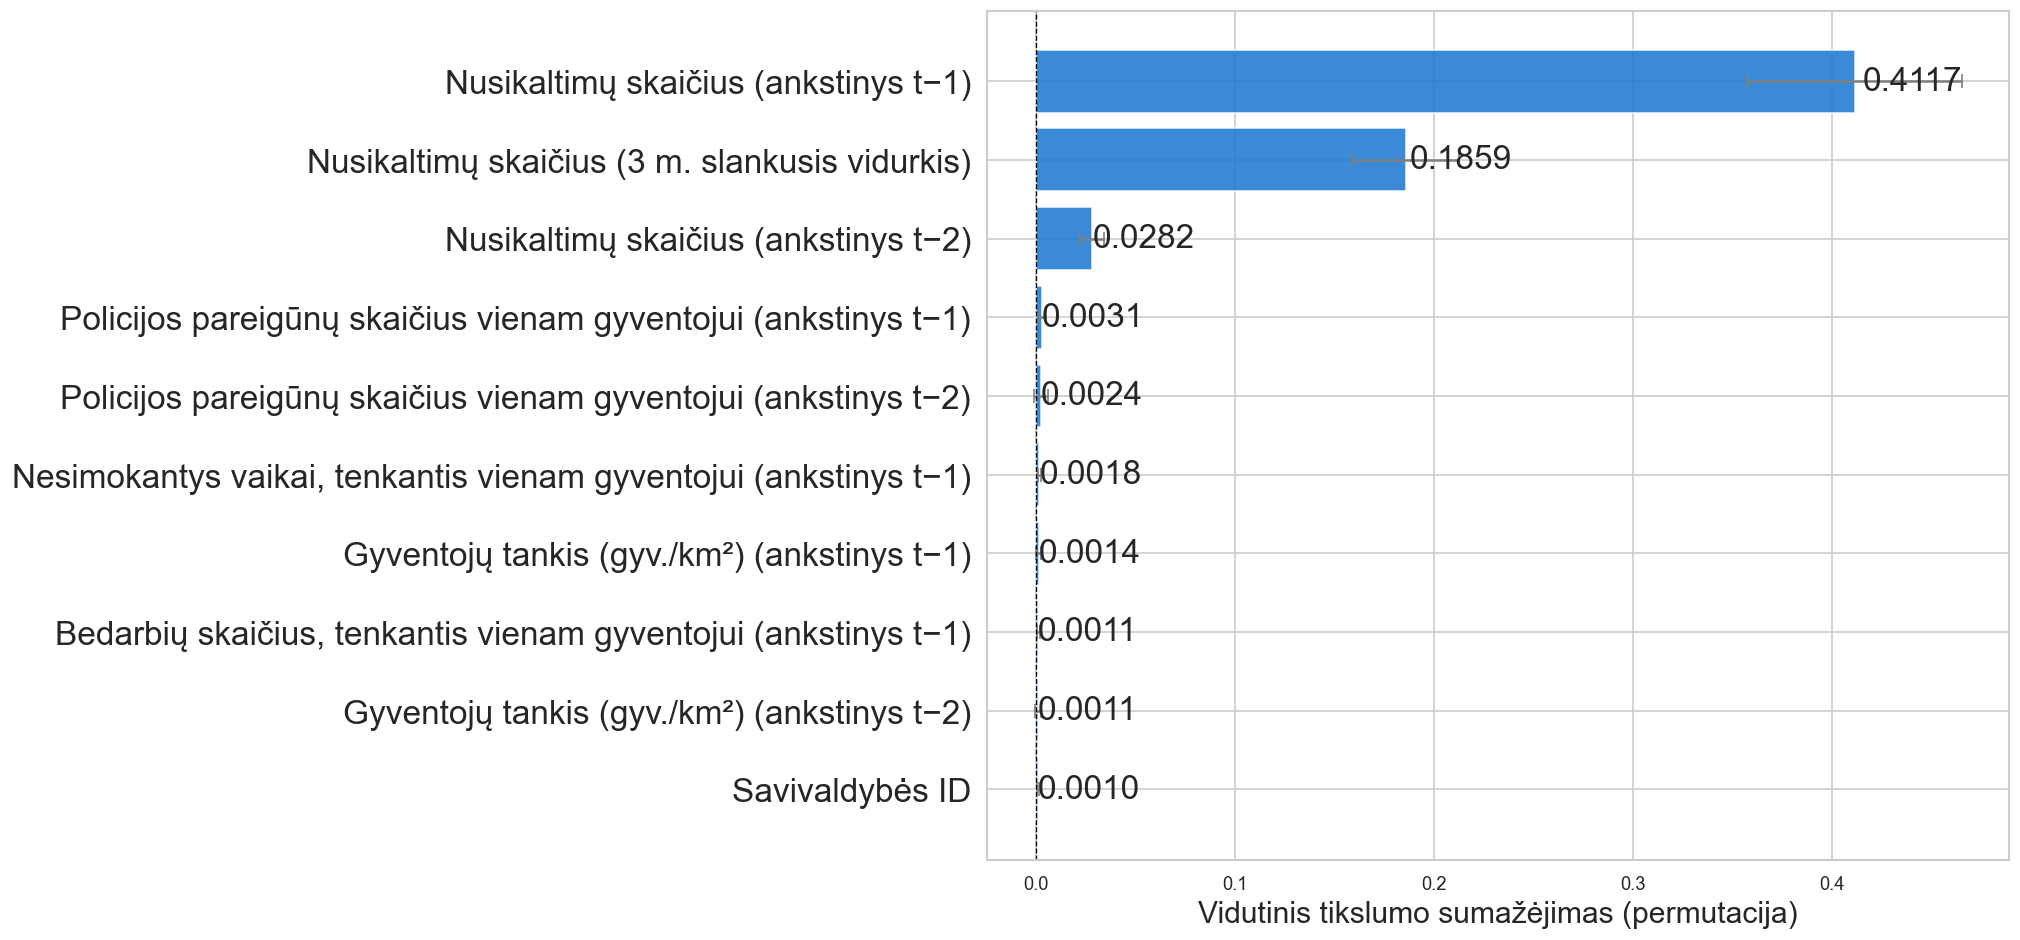

In [24]:
result = permutation_importance(
    rf_ns, X_test_nostl, y_test, n_repeats=10, random_state=4, n_jobs=2
)

perm_means = result.importances_mean
perm_std = result.importances_std

fi_perm = pd.DataFrame({
    "Feature": [nice_name(f) for f in BEST_FEATS],
    "Importance": perm_means,
    "Std": perm_std
})
fi_perm = fi_perm.sort_values("Importance").tail(10)

fig, ax = plt.subplots(figsize=(17, 8))
bars = ax.barh(
    fi_perm["Feature"],
    fi_perm["Importance"],
    xerr=fi_perm["Std"],
    color="#1976d2", alpha=0.85,
    error_kw={"elinewidth": 1.5, "capsize": 4, "ecolor": "gray"}
)
for bar, v in zip(bars, fi_perm["Importance"]):
    ax.text(bar.get_width() + bar.get_width()*0.01,
            bar.get_y() + bar.get_height()/2,
            f"{v:.4f}", va="center", fontsize=20)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Vidutinis tikslumo sumažėjimas (permutacija)", fontsize=18)
ax.tick_params(axis='y', labelsize=20)
plt.tight_layout()
plt.show()

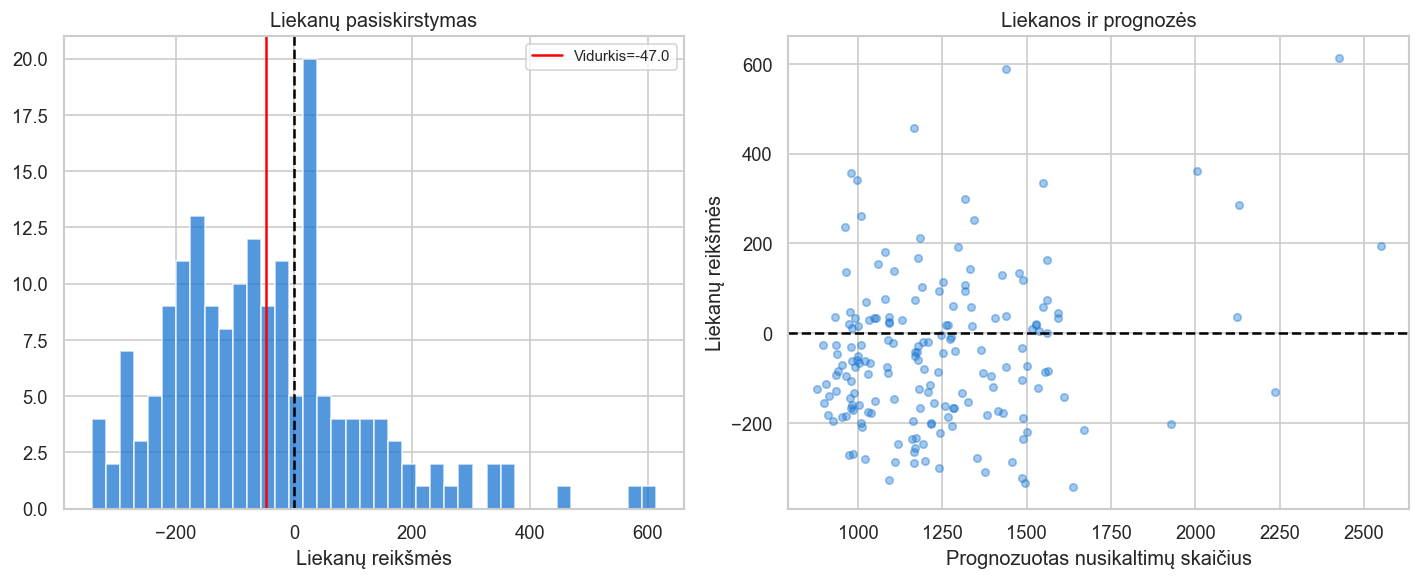

In [25]:
residuals = y_test_orig - BEST_PRED  # originalaus masto liekaųjų nuokrypių
test_r = test.reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pasiskirstymas
axes[0].hist(residuals, bins=40, color='#1976d2', alpha=0.75, edgecolor='white')
axes[0].axvline(0, color='black', lw=1.5, linestyle='--')
axes[0].axvline(np.mean(residuals), color='red', lw=1.5, linestyle='-',
                label=f'Vidurkis={np.mean(residuals):.1f}')
axes[0].set_title('Liekanų pasiskirstymas')
axes[0].set_xlabel('Liekanų reikšmės')
axes[0].legend(fontsize=9)

# Liekanos ir prognozės
axes[1].scatter(BEST_PRED, residuals, alpha=0.4, color='#1976d2', s=20)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Prognozuotas nusikaltimų skaičius')
axes[1].set_ylabel('Liekanų reikšmės')
axes[1].set_title('Liekanos ir prognozės')

plt.tight_layout()
plt.show()


## Didžiųjų miestų prognozė 2023–2025 (testinis laikotarpis)

Palyginimas: tikros reikšmės ir Random Forest prognozė kiekvienam iš penkių didžiausių miestų.

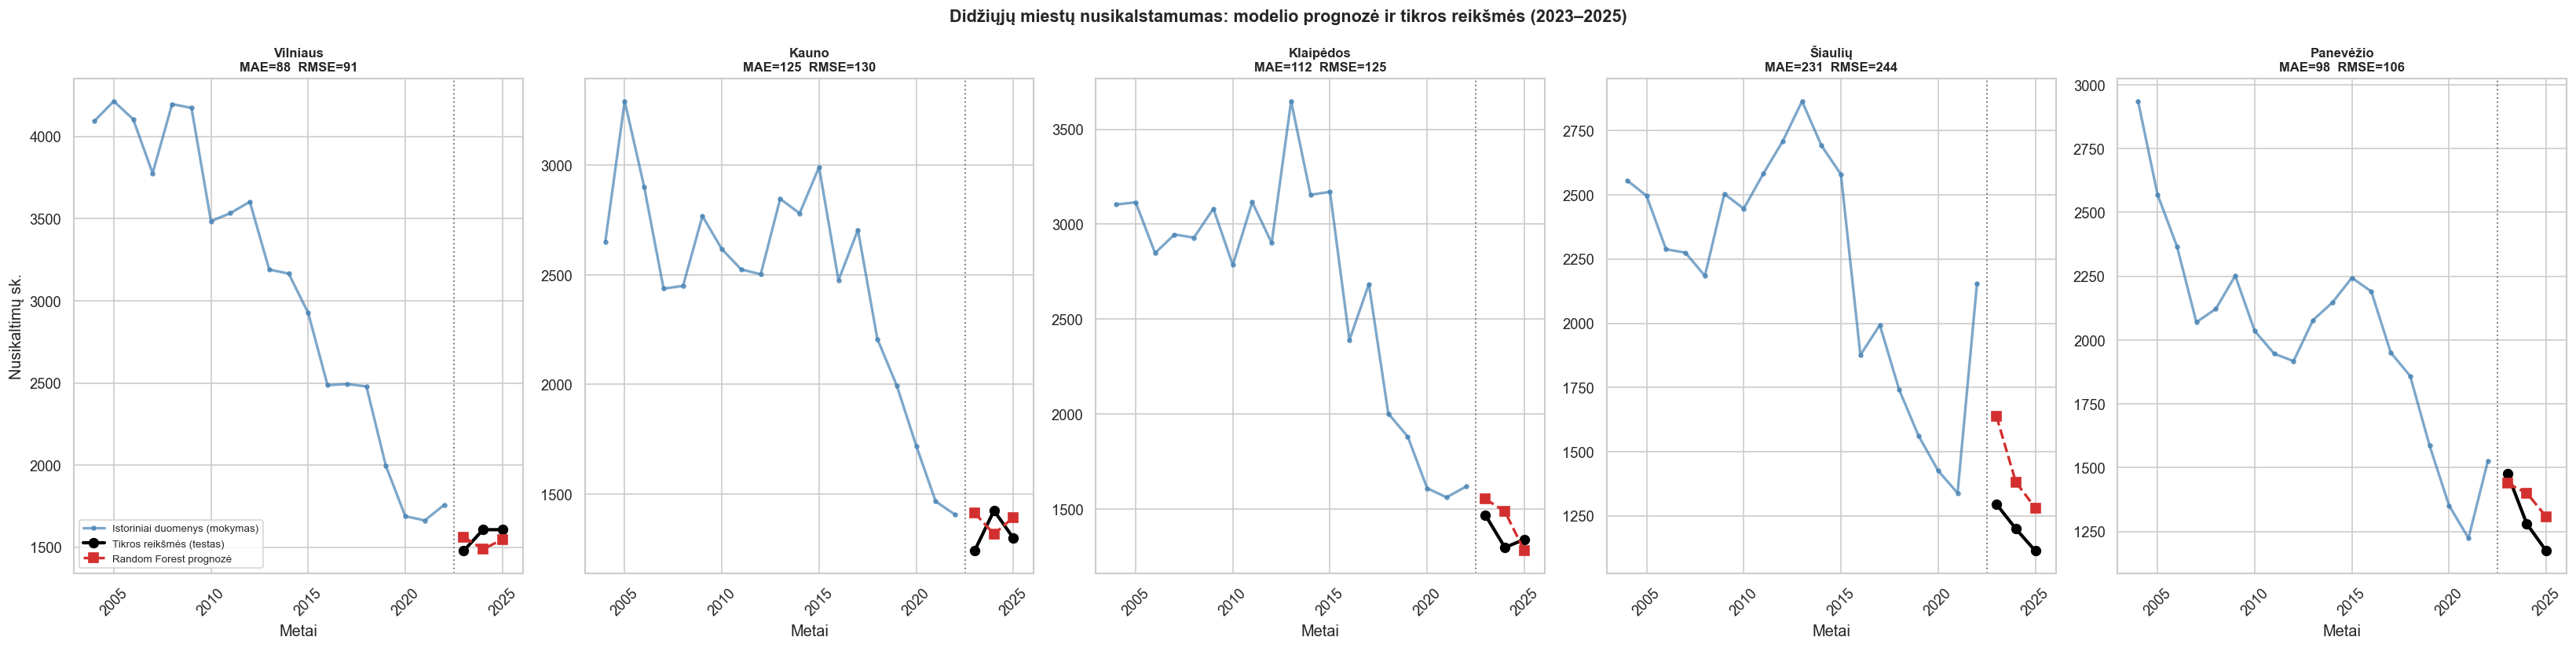

In [26]:
# Didžiųjų miestų prognozė testiniu laikotarpiu 2023–2025
MAJOR_CITIES_LIST = ['Vilniaus miestas', 'Kauno miestas', 'Klaipėdos miestas', 'Šiaulių miestas', 'Panevėžio miestas']
MAJOR_CITIES_TEST = [c for c in MAJOR_CITIES_LIST if c in test['Savivaldybė'].values]

test_aug = test[['Metai','Savivaldybė']].copy().reset_index(drop=True)
test_aug['Tikra'] = y_test_orig
test_aug['Progn'] = BEST_PRED

fig, axes = plt.subplots(1, len(MAJOR_CITIES_TEST),
                          figsize=(5.5 * len(MAJOR_CITIES_TEST), 7), sharey=False)
if len(MAJOR_CITIES_TEST) == 1:
    axes = [axes]
fig.suptitle('Didžiųjų miestų nusikalstamumas: modelio prognozė ir tikros reikšmės (2023–2025)',
             fontsize=13, fontweight='bold')

for ax, city in zip(axes, MAJOR_CITIES_TEST):
    hist_tr = df[(df['Savivaldybė'] == city) & (df['Metai'] <= CUTOFF)].sort_values('Metai')
    city_test = test_aug[test_aug['Savivaldybė'] == city].sort_values('Metai')

    ax.plot(hist_tr['Metai'], hist_tr[TARGET], color='steelblue',
            lw=2, marker='o', ms=3, label='Istoriniai duomenys (mokymas)', alpha=0.7)
    ax.plot(city_test['Metai'], city_test['Tikra'], color='black',
            lw=2.5, marker='o', ms=7, label='Tikros reikšmės (testas)')
    ax.plot(city_test['Metai'], city_test['Progn'], color='#d32f2f',
            lw=2, linestyle='--', marker='s', ms=7, label='Random Forest prognozė')

    city_mae  = mean_absolute_error(city_test['Tikra'], city_test['Progn'])
    city_rmse = np.sqrt(mean_squared_error(city_test['Tikra'], city_test['Progn']))
    ax.axvline(CUTOFF + 0.5, color='gray', linestyle=':', lw=1.2)
    ax.set_title(f"{city.replace(' miestas','').replace(' savivaldybė','')}\n"
                 f"MAE={city_mae:.0f}  RMSE={city_rmse:.0f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Metai')
    ax.tick_params(axis='x', rotation=45)
    if ax == axes[0]:
        ax.set_ylabel('Nusikaltimų sk.')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# Prognozė 2026–2028

Random Forest be krypties mokomas iš naujo ant visų duomenų (2004–2025).


In [27]:
FC_FUTURE = [2026, 2027, 2028]

# Permokome RF ant visų duomenų (2004–2025)
dm_full = df_model.dropna(subset=FEATS_NOSTL + [TARGET])
rf_full = RandomForestRegressor(**best_rf_p_ns)
rf_full.fit(dm_full[FEATS_NOSTL], dm_full[TARGET])
yr_min = dm_full["Metai"].min(); yr_max = dm_full["Metai"].max()
ins_r2 = r2_score(dm_full[TARGET], rf_full.predict(dm_full[FEATS_NOSTL]))


In [28]:
N_TREND   = 5
FC_YEARS  = [2026, 2027, 2028]
muns      = df['Savivaldybė'].unique()

history = (df_model[['Metai','Savivaldybė', TARGET] + SELECTED].copy().sort_values(['Savivaldybė','Metai']).reset_index(drop=True))

fc_frames = []

for year in FC_YEARS:
    rows_features = []
    rows_exog     = {}

    for mun in muns:
        mun_h = history[history['Savivaldybė']==mun].sort_values('Metai')
        row   = {'Savivaldybe_id': int(le.transform([mun])[0])}

        # Target lags
        row[f'{TARGET}_lag1'] = float(mun_h[TARGET].iloc[-1])
        row[f'{TARGET}_lag2'] = float(mun_h[TARGET].iloc[-2])
        row[f'{TARGET}_roll3_mean'] = float(mun_h[TARGET].iloc[-3:].mean())
        row[f'{TARGET}_roll3_std'] = float(mun_h[TARGET].iloc[-3:].std() if len(mun_h) >= 3 else 0.0)
        row[f'{TARGET}_lag_delta']  = row[f'{TARGET}_lag1'] - row[f'{TARGET}_lag2']

        # linijinė ekstrapoliacija
        mun_last = mun_h.tail(N_TREND)
        t_vals = np.arange(len(mun_last))
        exog_proj = {}
        for feat in SELECTED:
            fv = mun_last[feat].values.astype(float)
            if len(fv) >= 2:
                slope, intercept = np.polyfit(t_vals, fv, 1)
                proj_val = float(intercept + slope * len(fv))
            else:
                proj_val = float(fv[-1])
            exog_proj[feat] = proj_val
            row[feat] = proj_val
            row[f'{feat}_lag1'] = float(mun_h[feat].iloc[-1])
            row[f'{feat}_lag2'] = float(mun_h[feat].iloc[-2])
            if f'{feat}_delta1' in FEATS_NOSTL:
                row[f'{feat}_delta1'] = float(mun_h[feat].iloc[-1] - mun_h[feat].iloc[-2])

        rows_exog[mun] = exog_proj
        rows_features.append({k: row.get(k, 0.0) for k in FEATS_NOSTL})

    # Prognozė
    X_fc = pd.DataFrame(rows_features, columns=FEATS_NOSTL)
    tree_preds = np.array([t.predict(X_fc) for t in rf_full.estimators_])
    pt_pred = tree_preds.mean(axis=0)
    pi_lo   = np.percentile(tree_preds,  5, axis=0)
    pi_hi   = np.percentile(tree_preds, 95, axis=0)

    # Atvirkštinė transformacija
    pt_pred_orig = inv_transform(pt_pred, transform_params[TARGET])
    pi_lo_orig   = inv_transform(pi_lo,   transform_params[TARGET])
    pi_hi_orig   = inv_transform(pi_hi,   transform_params[TARGET])

    frame = pd.DataFrame({
        'Metai': year, 'Savivaldybė': muns,
        TARGET: pt_pred_orig, 'PI_lo': pi_lo_orig, 'PI_hi': pi_hi_orig
    })
    fc_frames.append(frame)

    # Atnaujinti
    new_rows = []
    for i, mun in enumerate(muns):
        hr = {'Metai': year, 'Savivaldybė': mun, TARGET: float(pt_pred[i])}
        hr.update(rows_exog[mun])
        new_rows.append(hr)
    history = pd.concat([history,
                          pd.DataFrame(new_rows)[['Metai','Savivaldybė',TARGET]+SELECTED]],
                         ignore_index=True)

    print(f'{year}  panel vid = {pt_pred_orig.mean():.1f}  PI: [{pi_lo_orig.mean():.1f}–{pi_hi_orig.mean():.1f}]')

fc_df = pd.concat(fc_frames, ignore_index=True)
print(f'\nPrognozė: {len(fc_df)} eilutės ({len(muns)} sav. × {len(FC_YEARS)} metai)')


2026  panel vid = 1116.0  PI: [911.8–1410.7]
2027  panel vid = 1074.9  PI: [882.0–1379.8]
2028  panel vid = 1049.2  PI: [860.8–1357.1]

Prognozė: 177 eilutės (59 sav. × 3 metai)


In [29]:
history

,Metai,Savivaldybė,Nusikaltimu_vienam_gyventojui,Gyventoju_tankis,Moteru,Skurdas,Uzmokestis,alkoholio_iperkamumas,alkoholio_suvartojimas,tabako_suvartojimas,Bedarbiu_sk_vienam_gyventojui,Policija_vienam_gyventojui,Pasalpa_gaunantys_vienam_gyventojui,Vaikai_nesimokantys_vienam_gyventojui
0,2006,Akmenės rajonas,3.747553,1.266120,1154.000,25.0571,10.702231,0.644947,11.100000,1248.000000,0.053864,-12.933234,-2.114023,-2.379864
1,2007,Akmenės rajonas,3.729570,1.264105,1166.000,25.4262,11.010554,0.644944,11.700000,1285.000000,0.039190,-12.721503,-2.104223,-2.378697
2,2008,Akmenės rajonas,3.709000,1.262001,1180.000,25.7952,11.295494,0.644947,11.800000,1259.000000,0.043555,-12.249376,-2.054719,-2.377285
3,2009,Akmenės rajonas,3.766332,1.259800,1176.000,26.1643,11.560673,0.644935,11.100000,849.000000,0.089767,-12.151744,-1.818705,-2.376037
4,2010,Akmenės rajonas,3.774918,1.256902,1176.000,19.3000,11.808906,0.644933,11.600000,791.000000,0.122036,-12.179324,-1.549143,-2.347250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1352,2028,Šiaulių rajonas,3.676979,1.230254,1035.186,27.2740,18.237593,0.644990,7.934622,1008.522043,0.031322,-10.712253,-2.270154,-2.468144
1353,2028,Šilalės rajonas,3.646913,1.196162,1076.338,43.7026,17.808708,0.644990,7.934622,1008.522043,0.034875,-14.752457,-2.270982,-2.346764
1354,2028,Šilutės rajonas,3.704272,1.232350,1077.828,42.3888,18.088859,0.644990,7.934622,1008.522043,0.041746,-16.926945,-2.235452,-2.328538
1355,2028,Širvintų rajonas,3.673498,1.190028,1092.012,20.4186,18.356432,0.644990,7.934622,1008.522043,0.039175,-14.223370,-2.459216,-2.398114


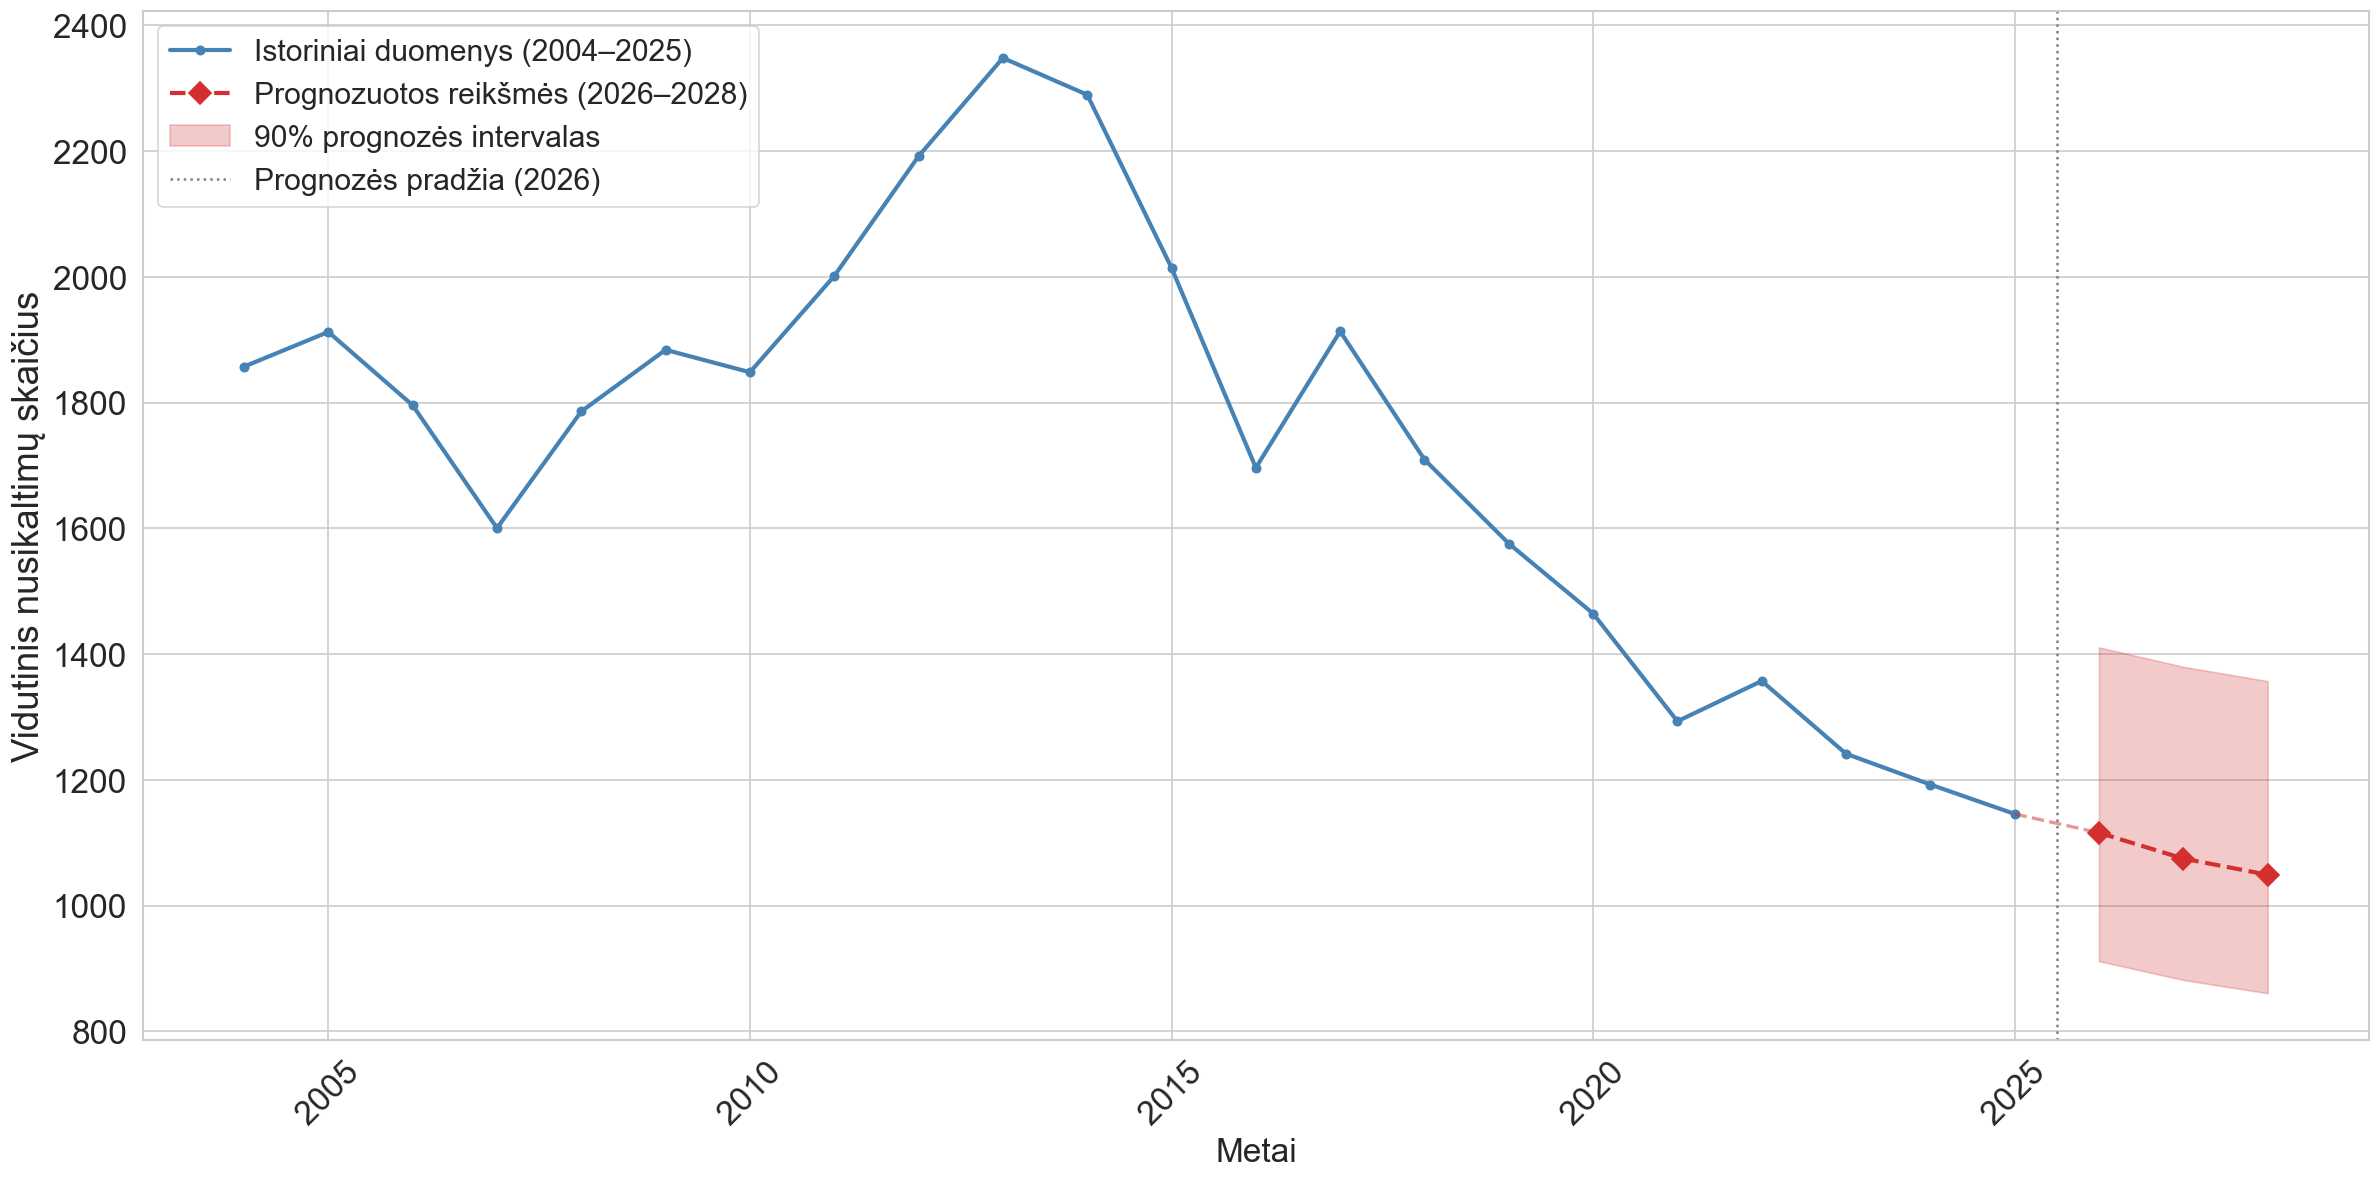

In [30]:
# vidurkio prognozė
hist_ann = df.groupby('Metai')[TARGET].mean()
fc_ann   = fc_df.groupby('Metai')[TARGET].mean()
fc_lo    = fc_df.groupby('Metai')['PI_lo'].mean()
fc_hi    = fc_df.groupby('Metai')['PI_hi'].mean()

fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(hist_ann.index, hist_ann.values, marker='o', color='steelblue',
        lw=2.5, label='Istoriniai duomenys (2004–2025)', ms=5)
ax.plot(fc_ann.index, fc_ann.values, marker='D', color='#d32f2f',
        lw=2.5, linestyle='--', label='Prognozuotos reikšmės (2026–2028)', ms=9, zorder=10)
ax.fill_between(fc_ann.index, fc_lo.values, fc_hi.values,
                alpha=0.25, color='#d32f2f', label='90% prognozės intervalas')
# Jungiamoji linija
ax.plot([2025, 2026], [hist_ann.iloc[-1], fc_ann.iloc[0]],
        color='#d32f2f', lw=2, linestyle='--', alpha=0.5)
ax.axvline(2025.5, color='gray', linestyle=':', lw=1.5, label='Prognozės pradžia (2026)')
ax.set_xlabel('Metai', fontsize=20)
ax.set_ylabel('Vidutinis nusikaltimų skaičius', fontsize=22)
ax.tick_params(axis='x', rotation=45, labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.legend(fontsize=18)


plt.tight_layout()
plt.show()

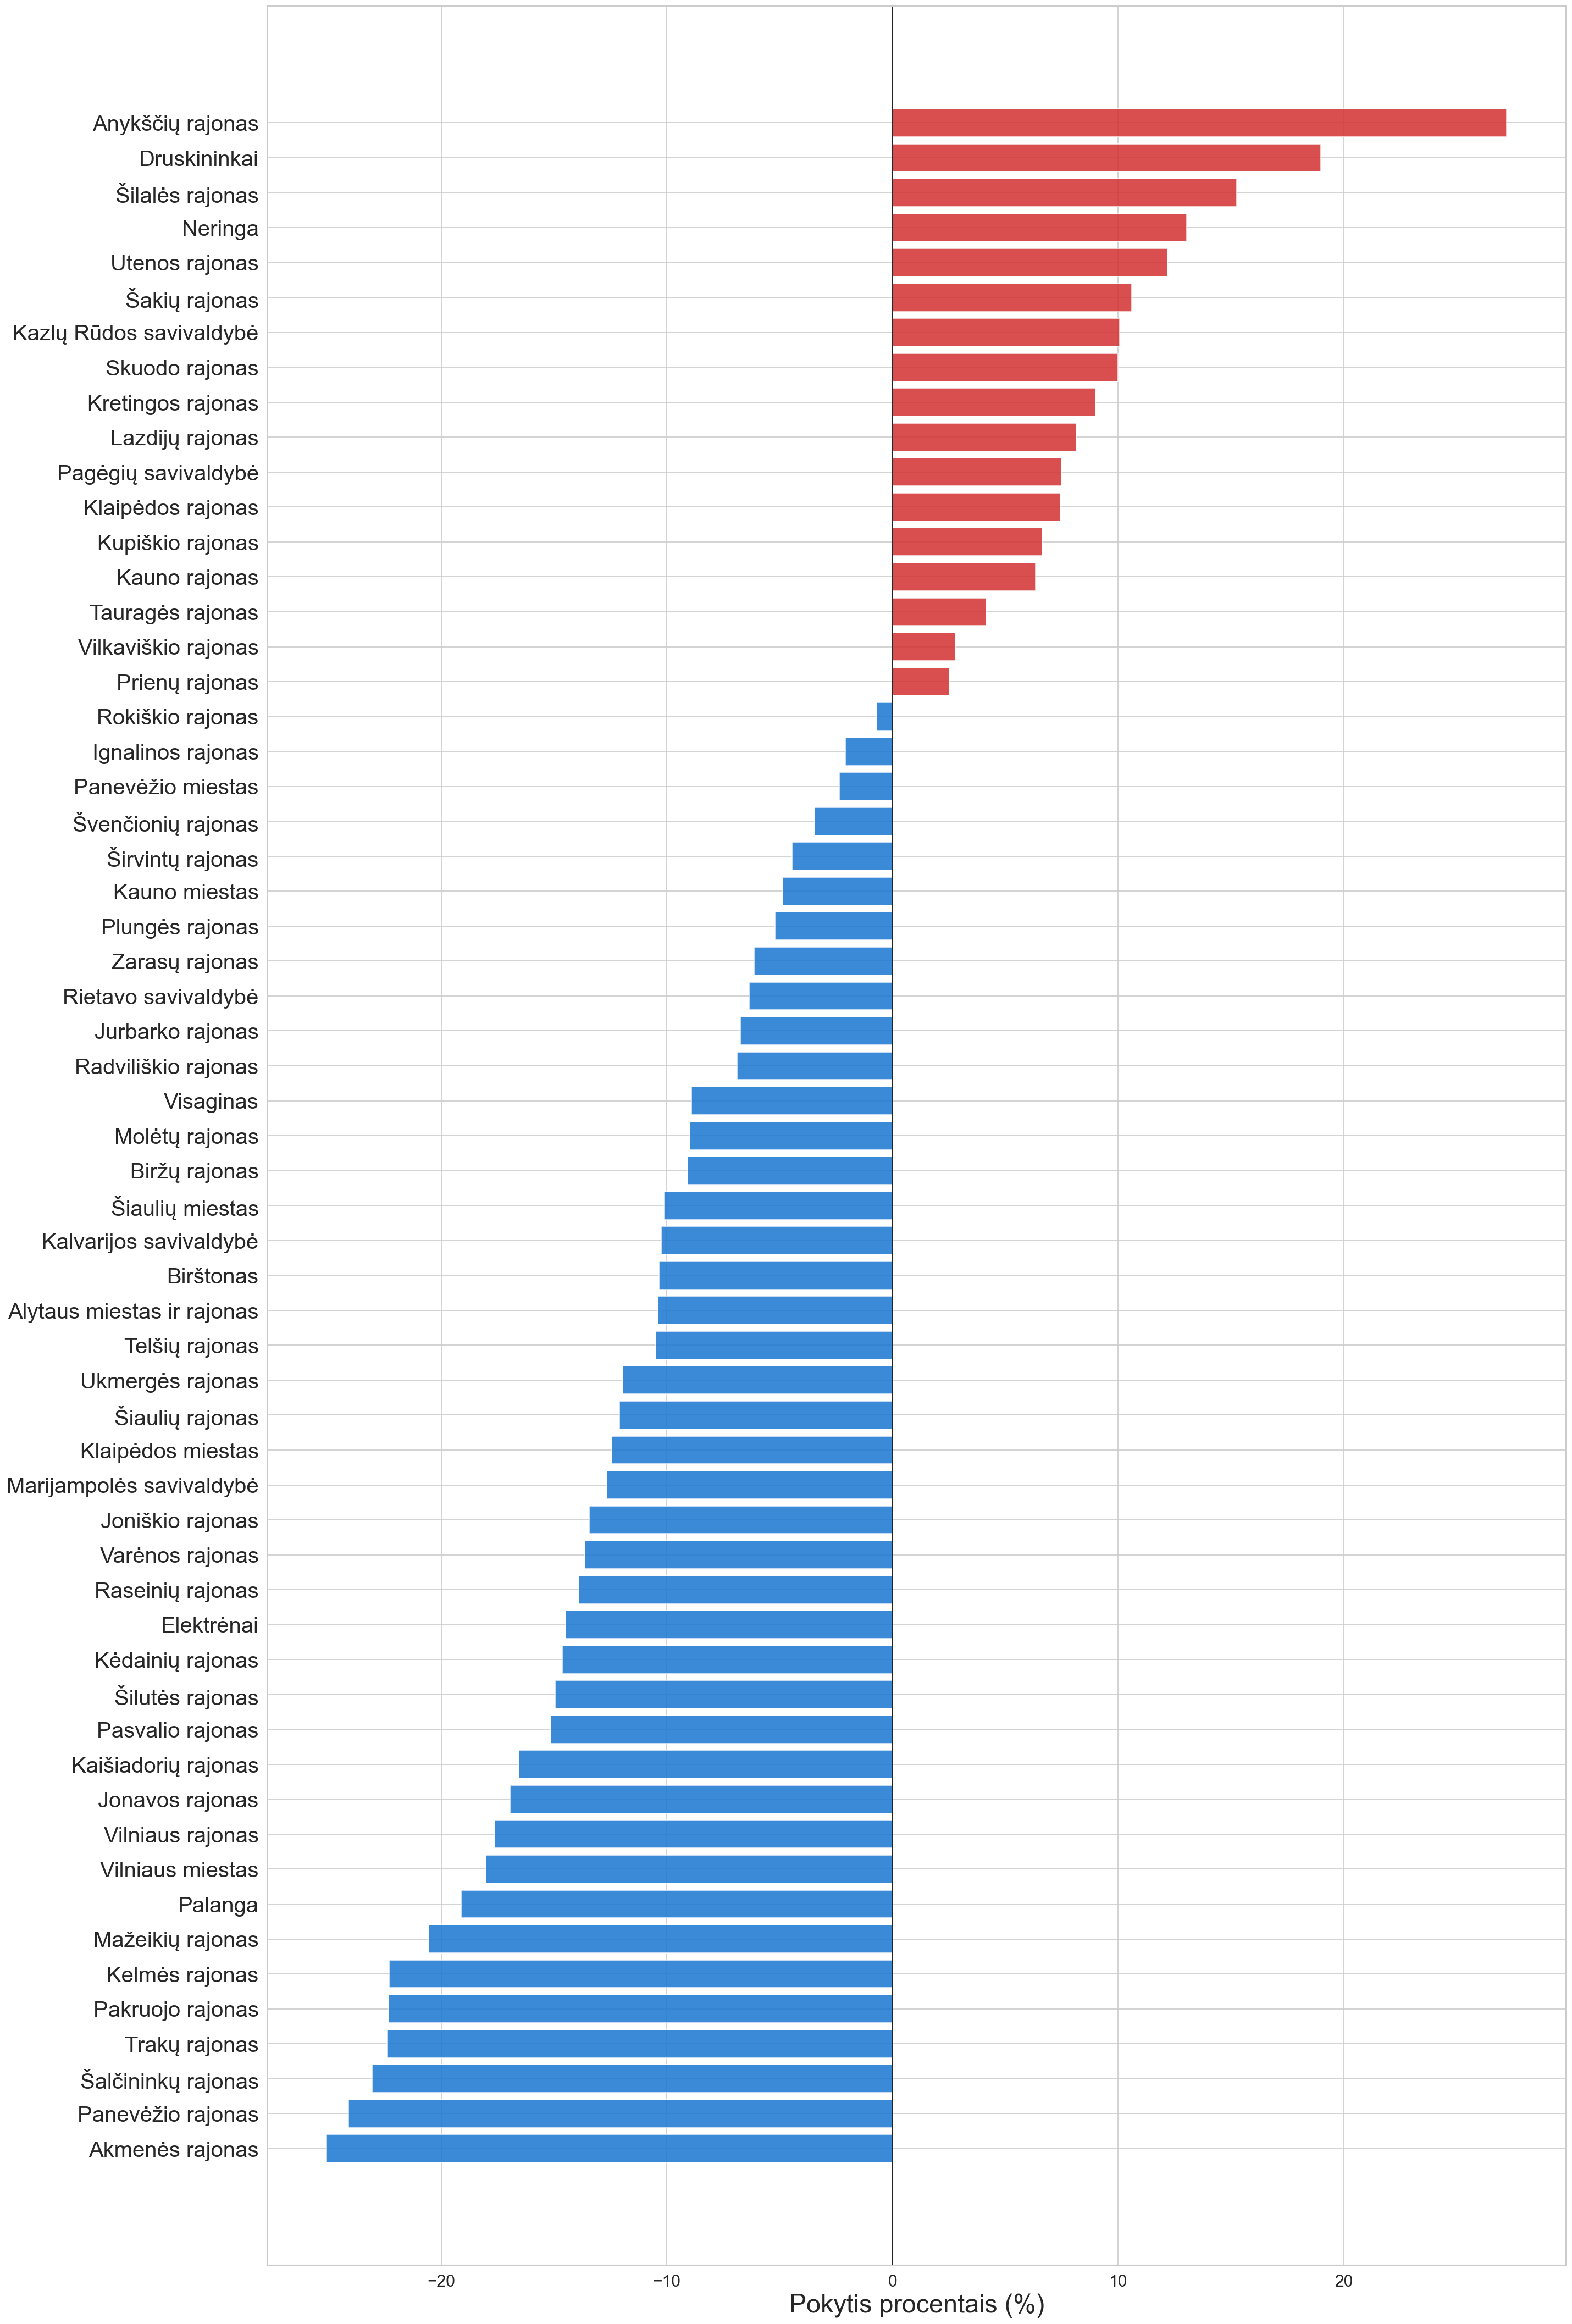

Top 5 augimo savivaldybės (2025-2028):
     Savivaldybė  Nusikaltimu_vienam_gyventojui  Tikra_2025  pokytis_%
Anykščių rajonas                     942.494508  740.808072  27.225194
    Druskininkai                     835.516985  702.156267  18.993025
 Šilalės rajonas                     842.057970  730.602504  15.255281
         Neringa                     863.142953  763.530204  13.046340
  Utenos rajonas                     861.051697  767.543860  12.182735

Top 5 mažėjimo savivaldybės:
       Savivaldybė  Nusikaltimu_vienam_gyventojui  Tikra_2025  pokytis_%
   Akmenės rajonas                    1000.905481 1336.079425 -25.086379
 Panevėžio rajonas                    1230.608768 1621.652164 -24.113889
Šalčininkų rajonas                    1227.958170 1596.137080 -23.066873
     Trakų rajonas                     901.518778 1161.690044 -22.395928
  Pakruojo rajonas                    1256.573203 1617.663753 -22.321731


In [31]:
# Savivaldybių 2028 prognozė
fc_2028 = fc_df[fc_df['Metai']==2028].copy()
last25  = df[df['Metai']==2025].groupby('Savivaldybė')[TARGET].mean().reset_index()
last25.columns = ['Savivaldybė','Tikra_2025']
fc_2028 = fc_2028.merge(last25, on='Savivaldybė', how='left')
fc_2028['pokytis_%'] = (fc_2028[TARGET]-fc_2028['Tikra_2025'])/fc_2028['Tikra_2025']*100

fc_sorted = fc_2028.sort_values('pokytis_%')
n = len(fc_sorted)
fig, ax = plt.subplots(figsize=(24, n * 0.6))
colors_ch = ['#d32f2f' if v>0 else '#1976d2' for v in fc_sorted['pokytis_%']]
ax.barh(fc_sorted['Savivaldybė'], fc_sorted['pokytis_%'], color=colors_ch, alpha=0.85)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Pokytis procentais (%)', fontsize=28)
ax.tick_params(axis='y', labelsize=24)
ax.tick_params(axis='x', labelsize=18)
plt.tight_layout()
plt.show()

print('Top 5 augimo savivaldybės (2025-2028):')
print(fc_2028.nlargest(5,'pokytis_%')[['Savivaldybė',TARGET,'Tikra_2025','pokytis_%']].to_string(index=False))
print('\nTop 5 mažėjimo savivaldybės:')
print(fc_2028.nsmallest(5,'pokytis_%')[['Savivaldybė',TARGET,'Tikra_2025','pokytis_%']].to_string(index=False))

In [32]:
# Prognozės suvestinė
last25 = df[df['Metai']==2025].groupby('Savivaldybė')[TARGET].mean().reset_index()
last25.columns = ['Savivaldybė', 'Tikra_2025']

piv = fc_df[['Savivaldybė', TARGET, 'PI_lo', 'PI_hi']].copy().round(1)
piv.columns = ['Savivaldybė', 'Prognozė_2026', 'PI_lo_90', 'PI_hi_90']
piv = piv.merge(last25, on='Savivaldybė', how='left')
piv['pokytis_%'] = ((piv['Prognozė_2026'] - piv['Tikra_2025']) / piv['Tikra_2025'] * 100).round(1)

m  = fc_df[TARGET].mean()
lo = fc_df['PI_lo'].mean()
hi = fc_df['PI_hi'].mean()
print(f'Panel vidurkiai:')
print(f'  Tikra 2025:    {df[df["Metai"]==2025][TARGET].mean():.1f}')
print(f'  Prognozė 2026: {m:.1f}  [90% PI: {lo:.1f}–{hi:.1f}]')
piv.sort_values('pokytis_%', ascending=False)

Panel vidurkiai:
  Tikra 2025:    1145.9
  Prognozė 2026: 1080.0  [90% PI: 884.9–1382.5]


,Savivaldybė,Prognozė_2026,PI_lo_90,PI_hi_90,Tikra_2025,pokytis_%
2,Anykščių rajonas,949.8,753.4,1336.7,740.808072,28.2
120,Anykščių rajonas,942.5,735.1,1308.0,740.808072,27.2
61,Anykščių rajonas,936.7,733.6,1303.6,740.808072,26.4
5,Druskininkai,835.9,713.4,1138.5,702.156267,19.0
64,Druskininkai,835.7,715.7,1159.1,702.156267,19.0
...,...,...,...,...,...,...
59,Akmenės rajonas,1034.1,801.3,1337.0,1336.079425,-22.6
170,Šalčininkų rajonas,1228.0,1055.7,1556.7,1596.137080,-23.1
149,Panevėžio rajonas,1230.6,1053.6,1504.0,1621.652164,-24.1
90,Panevėžio rajonas,1224.0,1046.9,1494.2,1621.652164,-24.5


In [33]:
# Prognozės lentel
piv = fc_df.pivot_table(index='Savivaldybė', columns='Metai', values=TARGET).round(1)
piv.columns = [f'Prognozė_{y}' for y in piv.columns]
piv.insert(0, 'Tikra_2025', last25.set_index('Savivaldybė')['Tikra_2025'])
print(f'Panel vidurkiai:')
print(f'  Tikra 2025:    {df[df["Metai"]==2025][TARGET].mean():.1f}')
for y in FC_YEARS:
    m = fc_df[fc_df['Metai']==y][TARGET].mean()
    lo = fc_df[fc_df['Metai']==y]['PI_lo'].mean()
    hi = fc_df[fc_df['Metai']==y]['PI_hi'].mean()
    print(f'  Prognozė {y}: {m:.1f}  [90% PI: {lo:.1f}–{hi:.1f}]')
piv.head(10)

Panel vidurkiai:
  Tikra 2025:    1145.9
  Prognozė 2026: 1116.0  [90% PI: 911.8–1410.7]
  Prognozė 2027: 1074.9  [90% PI: 882.0–1379.8]
  Prognozė 2028: 1049.2  [90% PI: 860.8–1357.1]


,Tikra_2025,Prognozė_2026,Prognozė_2027,Prognozė_2028
Savivaldybė,,,,
Akmenės rajonas,1336.079425,1151.7,1034.1,1000.9
Alytaus miestas ir rajonas,2414.608513,2241.4,2176.2,2163.4
Anykščių rajonas,740.808072,949.8,936.7,942.5
Birštonas,1292.367715,1177.7,1171.0,1158.5
Biržų rajonas,1267.101276,1222.8,1189.7,1151.9
Druskininkai,702.156267,835.9,835.7,835.5
Elektrėnai,967.558338,894.8,873.3,827.4
Ignalinos rajonas,1162.362981,1206.3,1167.1,1138.2
Jonavos rajonas,1454.501743,1348.9,1258.9,1208.1



## Didžiųjų miestų prognozė


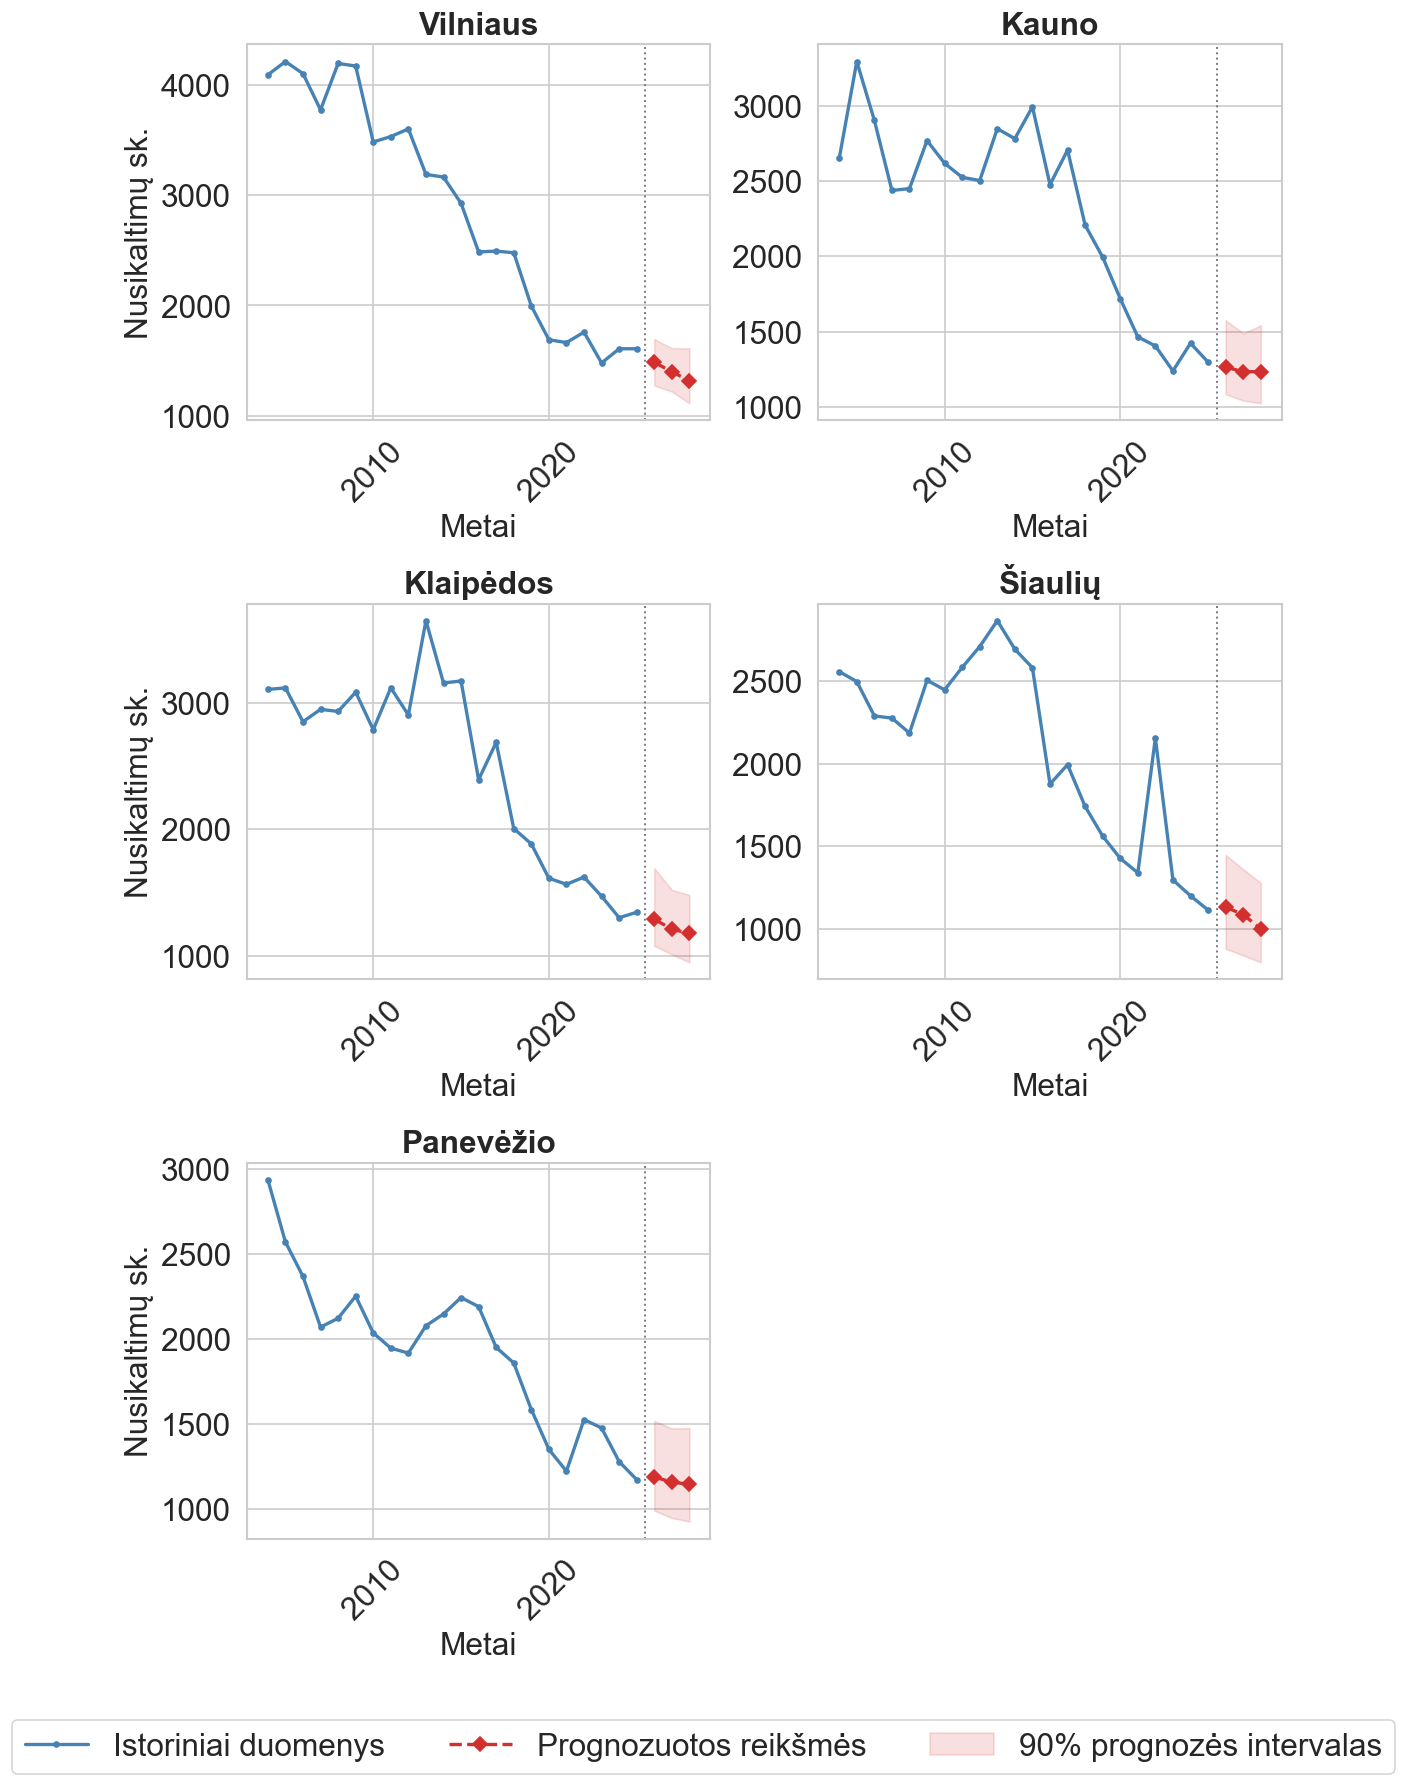

In [34]:
# Didžiųjų miestų prognozė 2026–2028
MAJOR_CITIES = ['Vilniaus miestas', 'Kauno miestas', 'Klaipėdos miestas',
                 'Šiaulių miestas', 'Panevėžio miestas']
MAJOR_CITIES = [c for c in MAJOR_CITIES if c in fc_df['Savivaldybė'].values]

ncols = 2
nrows = (len(MAJOR_CITIES) + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5 * nrows))
axes = axes.flatten()

handles = None
for i, (ax, city) in enumerate(zip(axes, MAJOR_CITIES)):
    hist = df[df['Savivaldybė']==city].sort_values('Metai')
    fc   = fc_df[fc_df['Savivaldybė']==city].sort_values('Metai')

    l1, = ax.plot(hist['Metai'], hist[TARGET], color='steelblue',
            lw=2, marker='o', ms=3, label='Istoriniai duomenys')
    l2, = ax.plot(fc['Metai'], fc[TARGET], color='#d32f2f',
            lw=2, linestyle='--', marker='D', ms=6, label='Prognozuotos reikšmės')
    l3 = ax.fill_between(fc['Metai'], fc['PI_lo'], fc['PI_hi'],
                    color='#d32f2f', alpha=0.15, label='90% prognozės intervalas')
    ax.axvline(2025.5, color='gray', linestyle=':', lw=1.2)
    ax.set_title(city.replace(' miestas','').replace(' savivaldybė',''),
                 fontsize=19, fontweight='bold')
    ax.set_xlabel('Metai', fontsize=19)
    ax.tick_params(axis='x', rotation=45, labelsize=19)
    ax.tick_params(axis='y', labelsize=19)
    if i % ncols == 0:
        ax.set_ylabel('Nusikaltimų sk.', fontsize=19)
    if handles is None:
        handles = [l1, l2, l3]

for ax in axes[len(MAJOR_CITIES):]:
    ax.set_visible(False)

fig.legend(handles=handles, loc='lower center', ncol=3,
           fontsize=19, bbox_to_anchor=(0.5, 0.0))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [35]:
# Lentelė
print(f'{"Miestas":<22} {"Tikra 2025":>12} {"2026":>8} {"2027":>8} {"2028":>8}')
print('-'*80)
for city in MAJOR_CITIES:
    t25 = df[(df['Savivaldybė']==city)&(df['Metai']==2025)][TARGET].values
    t25 = t25[0] if len(t25) else float('nan')
    row = [fc_df[(fc_df['Savivaldybė']==city)&(fc_df['Metai']==y)][TARGET].values
           for y in [2026,2027,2028]]
    row = [r[0] if len(r) else float('nan') for r in row]
    lbl = city.replace(' miestas','').replace(' savivaldybė','')
    print(f'{lbl:<22} {t25:>12.0f} {row[0]:>8.0f} {row[1]:>8.0f} {row[2]:>8.0f}')

Miestas                  Tikra 2025     2026     2027     2028
--------------------------------------------------------------------------------
Vilniaus                       1607     1484     1398     1318
Kauno                          1299     1266     1235     1235
Klaipėdos                      1342     1287     1209     1175
Šiaulių                        1114     1132     1086     1001
Panevėžio                      1174     1189     1159     1146
